<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V20e_Analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V17b — Transfer-Pipeline Sanity Check: HD → MA

**Zweck:** Debug-/Sanity-Notebook für die Transfer-Pipeline.
Prüft ob das Setup mit den finalen Anomalietypen (ohne Contextuals) methodisch plausibel funktioniert.

**Experimente:**
1. MA Oracle (Target-only 100%)
2. HD → MA Zero-Shot (Strict Pure)
3. HD → MA Zero-Shot (Calibrated / Target-Stats)
4. HD → MA Fine-Tune (5% Target-Train)

**Modelle:** Forecaster (LSTM dir+ZNorm) als Hauptmodell, AE (ZNorm Hour×Station) als Vergleich.

**Anomalietypen:** point_spike, point_drop, collective (keine contextuals).

In [1]:
# ══════════════════════════════════════════════════════════════
# 0a — Colab Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 0b — Imports
# ══════════════════════════════════════════════════════════════
import os, math, json, random, warnings, time, re, glob, copy, pickle
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve,
    classification_report
)
from numpy.lib.stride_tricks import sliding_window_view

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
print(f"TF {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")

TF 2.19.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ══════════════════════════════════════════════════════════════
# 0c — V20d Config
# ══════════════════════════════════════════════════════════════
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'

RUN_NAME    = 'v20d_spike_only'
RESULTS_DIR = f'{DATA_BASE}/{RUN_NAME}'
MODELS_DIR  = f'{RESULTS_DIR}/models'
PRELOAD_MODELS_DIR = MODELS_DIR

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Paths
geo_path           = f'{CLEANED_BASE}/geo_information/geo_information.parquet'
station_names_path = f'{DATA_BASE}/station_names/station_names.parquet'

# City-specific demand paths
CITY_DEMAND = {
    "Mannheim":   f'{CLEANED_BASE}/demand/Mannheim/demand_cleaned.parquet',
    "Heidelberg": f'{CLEANED_BASE}/demand/Heidelberg/demand_cleaned.parquet',
}

@dataclass
class V17bConfig:
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82
    min_events_per_day: float = 3.0
    rolling_days: int = 56
    min_context_obs: int = 20

    # Model architecture
    ae_window_size: int = 24
    ae_latent_dim: int = 32
    ae_layers: int = 2
    ae_dropout: float = 0.10
    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8
    eval_batch_size: int = 2048

    # Regime thresholds
    low_demand_q: float = 0.33
    high_demand_q: float = 0.67

    require_contiguous: bool = True
    use_bidirectional: bool = False

    # Features
    ae_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos", "is_weekend"
    ])
    ae_score_features: List[str] = field(default_factory=lambda: ["n_lends", "n_returns"])

    # Injection
    injection_rate: float = 0.015
    injection_seed: int = 42

    # Fine-tune
    finetune_ratio: float = 0.05

cfg = V17bConfig()
print(cfg)
print(f"\nResults: {RESULTS_DIR}")
print(f"Models : {MODELS_DIR}")


V17bConfig(aggregation_minutes=60, train_ratio=0.67, val_ratio=0.82, min_events_per_day=3.0, rolling_days=56, min_context_obs=20, ae_window_size=24, ae_latent_dim=32, ae_layers=2, ae_dropout=0.1, ae_epochs=50, ae_batch_size=2048, ae_lr=0.001, ae_early_stop=8, eval_batch_size=2048, low_demand_q=0.33, high_demand_q=0.67, require_contiguous=True, use_bidirectional=False, ae_features=['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend'], ae_score_features=['n_lends', 'n_returns'], injection_rate=0.015, injection_seed=42, finetune_ratio=0.05)

Results: /content/drive/MyDrive/BA_Colab/data/v20d_spike_only
Models : /content/drive/MyDrive/BA_Colab/data/v20d_spike_only/models


---
## Shared Functions (aus V17 übernommen)

In [4]:
# ══════════════════════════════════════════════════════════════
# 1 — Aggregation
# ══════════════════════════════════════════════════════════════
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60,
                            add_relative: bool = False) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)

    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({
            "n_lends": "sum",
            "n_returns": "sum",
            "latitude": "first",
            "longitude": "first"
        })
        .rename(columns={"time_bin": "hour_ts"})
    )

    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()

    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)

    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)

    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg

In [5]:
# ══════════════════════════════════════════════════════════════
# 2 — Gap-Fill
# ══════════════════════════════════════════════════════════════
def fill_missing_time_bins(x: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []
    x = x.copy().sort_values(["station_id", "hour_ts"])
    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg({
             "station_name_id": "first", "station_name": "first",
             "location_id": "first", "latitude": "first",
             "longitude": "first", "n_lends": "sum", "n_returns": "sum",
         })
    )
    key_cols = ["station_id", "station_name_id", "station_name",
                "location_id", "latitude", "longitude"]

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()
        full_idx = pd.date_range(g["hour_ts"].min(), g["hour_ts"].max(), freq=freq)
        g = g.set_index("hour_ts").reindex(full_idx)
        g.index.name = "hour_ts"
        g["n_lends"]   = g["n_lends"].fillna(0).astype(int)
        g["n_returns"] = g["n_returns"].fillna(0).astype(int)
        for col in key_cols:
            g[col] = g[col].ffill().bfill()
        parts.append(g.reset_index())

    result = pd.concat(parts, ignore_index=True)
    result["total_demand"] = result["n_lends"] + result["n_returns"]
    result["net_flow"]     = result["n_returns"] - result["n_lends"]
    result["abs_net_flow"] = result["net_flow"].abs()

    result["hour"] = result["hour_ts"].dt.hour
    result["dow"]  = result["hour_ts"].dt.dayofweek
    result["month"] = result["hour_ts"].dt.month
    result["is_weekend"] = result["dow"].isin([5, 6]).astype(int)

    result["hour_sin"]  = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"]  = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"]   = np.sin(2 * np.pi * result["dow"] / 7)
    result["dow_cos"]   = np.cos(2 * np.pi * result["dow"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)

    return result.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

In [6]:
# ══════════════════════════════════════════════════════════════
# 3 — Station-Filter, Demand-Regime, Train/Val/Test Split
# ══════════════════════════════════════════════════════════════
def prepare_stations_and_splits(df: pd.DataFrame, cfg, city_name=""):
    n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)

    station_volume = df.groupby("station_id")["total_demand"].sum()
    active_ids = station_volume[station_volume >= min_events].index.tolist()
    df = df[df["station_id"].isin(active_ids)].copy()

    station_profile = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              avg_total_demand_h=("total_demand", "mean"),
              avg_lends_h=("n_lends", "mean"),
              avg_returns_h=("n_returns", "mean"),
              latitude=("latitude", "first"),
              longitude=("longitude", "first")
          )
    )
    q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
    q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)
    station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(
        lambda x: "low" if x <= q1 else ("mid" if x <= q2 else "high")
    )
    df = df.merge(
        station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
        on="station_id", how="left"
    )

    t_min = df["hour_ts"].min()
    t_max = df["hour_ts"].max()
    total_h = (t_max - t_min).total_seconds() / 3600

    train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))

    cn = f" ({city_name})" if city_name else ""
    print(f"  Aktive Stationen{cn}: {df['station_id'].nunique()}")
    print(f"  Regime: {station_profile['demand_regime'].value_counts().to_dict()}")
    print(f"  Zeitraum: {t_min.date()} bis {t_max.date()} ({n_days} Tage)")
    print(f"  Split: Train < {train_end.date()}, Val < {val_end.date()}, Test ab {val_end.date()}")

    return df, station_profile, train_end, val_end

In [7]:
# ══════════════════════════════════════════════════════════════
# 4 — Rolling Context z-Scores + Poisson + ECDF + Labels
# ══════════════════════════════════════════════════════════════
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_context_keys(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

def rolling_context_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    mu_col    = f"{target}_mu_ctx_roll"
    sd_col    = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"

    n_slots = max(rolling_days // 7, 4)
    main_window = n_slots
    main_minp   = min(min_obs, main_window)

    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean()
    )
    rolling_std = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0)
    )

    fb1_window = n_slots * 2
    fb1_minp   = min(min_obs, fb1_window)
    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean()
    )
    fb1_std = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0)
    )

    fb2_window = n_slots * 4
    fb2_minp   = min(min_obs, fb2_window)
    grouped_s = x.groupby(["station_id"])[target]
    fb2_mean = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).mean()
    )
    fb2_std = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).std(ddof=0)
    )

    mu = rolling_mean.copy()
    sd = rolling_std.copy()
    mask1 = mu.isna()
    mu = mu.where(~mask1, fb1_mean)
    sd = sd.where(~mask1, fb1_std)
    mask2 = mu.isna()
    mu = mu.where(~mask2, fb2_mean)
    sd = sd.where(~mask2, fb2_std)
    sd = sd.clip(lower=1e-6)
    z = (x[target] - mu) / sd

    x[mu_col]    = mu
    x[sd_col]    = sd
    x[score_col] = z
    return x


def add_rolling_poisson_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    lam_col       = f"{target}_lambda_ctx_roll"
    score_col     = f"{target}_poisson_upper_score"
    score_low_col = f"{target}_poisson_lower_score"
    mu_col        = f"{target}_mu_ctx_roll"

    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")

    x[lam_col] = x[mu_col].clip(lower=1e-6)
    vals = x[target].values
    lams = x[lam_col].values

    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score  = -np.log10(np.clip(tail_p, 1e-12, None))
        lower_p   = poisson.cdf(vals.astype(float), lams.astype(float))
        score_low = -np.log10(np.clip(lower_p, 1e-12, None))

    mask_nan = np.isnan(lams)
    score[mask_nan]     = np.nan
    score_low[mask_nan] = np.nan

    x[score_col]     = score
    x[score_low_col] = score_low
    return x


def percentile_score(train_vals: np.ndarray, values: np.ndarray) -> np.ndarray:
    train_vals = np.asarray(train_vals, dtype=float)
    values     = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)
    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)

def calibrate_scores_by_station(
    full_df: pd.DataFrame, train_mask: pd.Series, raw_score_cols: List[str]
) -> pd.DataFrame:
    x = full_df.copy()
    for col in raw_score_cols:
        if col not in x.columns:
            continue
        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan
        for sid, grp in x.groupby("station_id", sort=False):
            idx_all   = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]
            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals       = x.loc[idx_all, col].to_numpy(dtype=float)
            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)
    return x

def build_eval_labels_calibrated(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    z_up = "total_demand_score_upper_pct_station"
    z_low = "total_demand_score_lower_pct_station"
    p_up  = "total_demand_poisson_upper_score_pct_station"
    p_low = "total_demand_poisson_lower_score_pct_station"

    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten: {missing}")

    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]

    abs_min_high    = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)

    high_strong    = ((y[z_up] >= 0.995) | (y[p_up] >= 0.995)) & (td >= abs_min_high)
    high_consensus = ((y[z_up] >= 0.99) & (y[p_up] >= 0.99)) & (td >= abs_min_high)
    cond_high = high_strong | high_consensus

    low_possible  = mu >= abs_min_low_ref
    low_strong    = ((y[z_low] >= 0.999) | (y[p_low] >= 0.999)) & low_possible
    low_consensus = ((y[z_low] >= 0.995) & (y[p_low] >= 0.995)) & low_possible
    cond_low = (low_strong | low_consensus) & ~cond_high

    grau_high = ((y[z_up] >= 0.99) | (y[p_up] >= 0.99)) & ~cond_high & ~cond_low
    grau_low  = ((y[z_low] >= 0.99) | (y[p_low] >= 0.99)) & ~cond_high & ~cond_low & ~grau_high

    y.loc[grau_high, "label_eval"] = "grauzone_high"
    y.loc[grau_low,  "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low,  "label_eval"] = "anomal_low"
    return y


def run_statistical_pipeline(df: pd.DataFrame, cfg, train_end):
    print("  [1/5] Kontext-Keys...")
    df = add_context_keys(df)
    print("  [2/5] Rolling z-Scores...")
    for tgt in TARGETS:
        df = rolling_context_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )
    for tgt in TARGETS:
        zc = f"{tgt}_z_ctx_roll"
        df[f"{tgt}_score_upper"] = df[zc]
        df[f"{tgt}_score_lower"] = -df[zc]

    print("  [3/5] Poisson-Tail-Scores...")
    for tgt in COUNT_TARGETS:
        df = add_rolling_poisson_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )

    print("  [4/5] ECDF-Kalibrierung...")
    raw_score_cols = []
    for tgt in TARGETS:
        raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
    for tgt in COUNT_TARGETS:
        raw_score_cols += [f"{tgt}_poisson_upper_score", f"{tgt}_poisson_lower_score"]

    train_mask = df["hour_ts"] < train_end
    df = calibrate_scores_by_station(df, train_mask, raw_score_cols)

    print("  [5/5] Labels...")
    df = build_eval_labels_calibrated(df)

    anomaly_rate = df["label_eval"].isin(["anomal_high", "anomal_low"]).mean()
    print(f"  Label-Verteilung:")
    print(f"    {df['label_eval'].value_counts().to_dict()}")
    print(f"    Anomalie-Rate: {anomaly_rate:.4f} ({anomaly_rate*100:.2f}%)")
    return df

In [8]:
# ══════════════════════════════════════════════════════════════
# 5 — Sequenzbuilder (Window-Level Labels)
# ══════════════════════════════════════════════════════════════
def make_sequences_with_window_labels(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    synth_label_col: str = "synth_label",
    synth_type_col: str = "synth_type",
    require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame]:
    X_parts, meta_parts = [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]
        X_parts.append(win[valid_mask])

        meta_chunk = g.iloc[end_indices].copy()

        synth_arr = g[synth_label_col].to_numpy()
        type_arr  = g[synth_type_col].to_numpy()

        window_labels, window_types, window_counts = [], [], []
        for end_idx in end_indices:
            start_idx = end_idx - window_size + 1
            window_synth = synth_arr[start_idx:end_idx + 1]
            window_type  = type_arr[start_idx:end_idx + 1]

            has_synth = int(window_synth.max())
            n_synth   = int(window_synth.sum())

            if has_synth:
                synth_positions = np.where(window_synth == 1)[0]
                wtype = window_type[synth_positions[-1]]
            else:
                wtype = "none"

            window_labels.append(has_synth)
            window_types.append(wtype)
            window_counts.append(n_synth)

        meta_chunk["window_synth_label"] = window_labels
        meta_chunk["window_synth_type"]  = window_types
        meta_chunk["n_synth_in_window"]  = window_counts
        meta_parts.append(meta_chunk)

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()

    return X, meta

In [9]:
# ══════════════════════════════════════════════════════════════
# 6 — Model Builders (AE + Forecaster)
# ══════════════════════════════════════════════════════════════
def build_lstm_autoencoder(
    n_input_features: int,
    window_size: int,
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1,
    bidirectional: bool = False,
    n_output_features: Optional[int] = None,
) -> keras.Model:
    n_output_features = n_output_features or n_input_features
    inputs = keras.Input(shape=(window_size, n_input_features), name="encoder_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        lstm = layers.LSTM(
            latent_dim, return_sequences=return_sequences,
            dropout=dropout, name=f"encoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"encoder_bi_{i+1}")(x) if bidirectional else lstm(x)
    latent = x
    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)
    for i in range(n_layers):
        lstm = layers.LSTM(
            latent_dim, return_sequences=True,
            dropout=dropout, name=f"decoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"decoder_bi_{i+1}")(x) if bidirectional else lstm(x)
    outputs = layers.TimeDistributed(
        layers.Dense(n_output_features), name="output_dense"
    )(x)
    return keras.Model(inputs, outputs, name="lstm_autoencoder")


def build_lstm_forecaster(
    n_input_features: int,
    n_output_features: int,
    context_steps: int = 23,
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1,
) -> keras.Model:
    inputs = keras.Input(shape=(context_steps, n_input_features), name="forecast_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        x = layers.LSTM(
            latent_dim, return_sequences=return_sequences,
            dropout=dropout, name=f"forecast_lstm_{i+1}"
        )(x)
    outputs = layers.Dense(n_output_features, name="forecast_output")(x)
    return keras.Model(inputs, outputs, name="lstm_forecaster")


def train_model_generic(model, X_train, Y_train, X_val, Y_val,
                        epochs, lr, batch_size, early_stop, verbose=1):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="mse"
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=early_stop,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1
        )
    ]
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )
    return model, history

In [10]:
# ══════════════════════════════════════════════════════════════
# 7 — Scoring Helpers (AE + Forecaster)
# ══════════════════════════════════════════════════════════════
def predict_in_batches(model, X, batch_size=2048):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(model.predict(X[i:i + batch_size], verbose=0))
    return np.concatenate(preds, axis=0) if preds else np.empty((0, 0, 0), dtype=np.float32)


def compute_reconstruction_scores(X, X_hat, input_features, score_features,
                                  mode="last_step_mean"):
    score_idx = [input_features.index(c) for c in score_features]
    err = (X - X_hat) ** 2
    err_score = err[:, :, score_idx]
    if mode == "last_step_mean":
        return err_score[:, -1, :].mean(axis=1)
    elif mode == "window_mean":
        return err_score.mean(axis=(1, 2))
    elif mode == "max_over_features":
        return err_score[:, -1, :].max(axis=1)
    else:
        raise ValueError(f"Unbekannter mode: {mode}")


def compute_forecast_scores(model, X_input, X_actual_last_step, score_features,
                            ae_features, mode="directional"):
    X_pred = predict_in_batches(model, X_input, batch_size=2048)
    score_idx = [ae_features.index(f) for f in score_features]
    X_actual = X_actual_last_step[:, score_idx]
    err = (X_pred - X_actual) ** 2
    if mode == "mean":
        return err.mean(axis=1)
    elif mode == "max":
        return err.max(axis=1)
    elif mode == "directional":
        abs_err = np.abs(X_pred - X_actual)
        denom = np.maximum(np.maximum(np.abs(X_actual), np.abs(X_pred)), 1e-6)
        rel_err = abs_err / denom
        return 0.5 * abs_err.mean(axis=1) + 0.5 * rel_err.mean(axis=1)
    else:
        raise ValueError(f"Unbekannter mode: {mode}")

In [11]:
# ══════════════════════════════════════════════════════════════
# 8 — Z-Normalisierung (Hour + Hour×Station)
# ══════════════════════════════════════════════════════════════
def znorm_score_by_hour(meta_df, raw_score_col, val_start, test_start,
                        new_col="score_znorm_hour"):
    meta = meta_df.copy()
    val_normal = (
        (meta["hour_ts"] >= val_start) &
        (meta["hour_ts"] < test_start) &
        (meta["synth_label"] == 0)
    )
    hour_col = meta["hour_ts"].dt.hour
    mu_per_hour = {}
    std_per_hour = {}
    for h in range(24):
        vals = meta.loc[val_normal & (hour_col == h), raw_score_col].dropna()
        mu_per_hour[h]  = vals.mean() if len(vals) > 0 else 0.0
        std_per_hour[h] = vals.std()  if len(vals) > 1 else 1.0

    hours = hour_col.values
    raw   = meta[raw_score_col].values
    znorm = np.zeros_like(raw)
    for i in range(len(raw)):
        h = hours[i]
        znorm[i] = (raw[i] - mu_per_hour[h]) / max(std_per_hour[h], 1e-8)
    meta[new_col] = znorm
    return meta, mu_per_hour, std_per_hour


def znorm_score_by_hour_station(meta_df, raw_score_col, val_start, test_start,
                                new_col="score_znorm_hour_station"):
    meta = meta_df.copy()
    val_normal = (
        (meta["hour_ts"] >= val_start) &
        (meta["hour_ts"] < test_start) &
        (meta["synth_label"] == 0)
    )
    hour_col = meta["hour_ts"].dt.hour
    meta["_hour_tmp"] = hour_col

    stats = (
        meta[val_normal]
        .groupby(["station_id", "_hour_tmp"])[raw_score_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    global_stats = (
        meta[val_normal]
        .groupby("_hour_tmp")[raw_score_col]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "g_mean", "std": "g_std"})
    )
    stats = stats.merge(global_stats, on="_hour_tmp", how="left")
    stats["use_mean"] = np.where(stats["count"] >= 10, stats["mean"], stats["g_mean"])
    stats["use_std"]  = np.where(stats["count"] >= 10, stats["std"],  stats["g_std"])
    stats["use_std"]  = stats["use_std"].clip(lower=1e-8)

    meta = meta.merge(
        stats[["station_id", "_hour_tmp", "use_mean", "use_std"]],
        on=["station_id", "_hour_tmp"], how="left"
    )
    meta["use_mean"] = meta["use_mean"].fillna(0.0)
    meta["use_std"]  = meta["use_std"].fillna(1.0).clip(lower=1e-8)
    meta[new_col] = (meta[raw_score_col] - meta["use_mean"]) / meta["use_std"]
    meta = meta.drop(columns=["_hour_tmp", "use_mean", "use_std"])
    return meta

In [12]:
# ══════════════════════════════════════════════════════════════
# 9 — Synthetic Injection (V17b: OHNE Contextuals)
# ══════════════════════════════════════════════════════════════
# Original V17 balanced probs: [spike=0.35, drop=0.30, ctx=0.25, coll=0.10]
# Ohne contextuals, renormiert auf 3 Typen:
# spike = 0.35/(0.35+0.30+0.10) = 0.467
# drop  = 0.30/(0.35+0.30+0.10) = 0.400
# coll  = 0.10/(0.35+0.30+0.10) = 0.133

V17B_INJECTION_PROBS = {
    "point_spike": 1.0
}
V17B_COLLECTIVE_BLOCK_LEN = (2, 4)

def inject_synthetic_anomalies_v17b(
    df: pd.DataFrame,
    inject_start: pd.Timestamp,
    injection_rate: float = 0.015,
    seed: int = 42,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Injection ohne contextuals.
    Gibt zusätzlich requested vs actually injected counts zurück.
    """
    probs = list(V17B_INJECTION_PROBS.values())
    type_names = list(V17B_INJECTION_PROBS.keys())
    block_min, block_max = V17B_COLLECTIVE_BLOCK_LEN

    rng = np.random.RandomState(seed)
    out = df.copy()

    out["original_n_lends"]   = out["n_lends"].copy()
    out["original_n_returns"] = out["n_returns"].copy()
    out["synth_label"] = 0
    out["synth_type"]  = "none"

    inject_mask = out["hour_ts"] >= inject_start
    inject_idx  = out[inject_mask].index.to_numpy()

    if len(inject_idx) == 0:
        print("  WARNUNG: Keine Daten ab inject_start!")
        return out

    n_inject = max(1, int(len(inject_idx) * injection_rate))
    inject_df = out.loc[inject_idx]
    has_demand = inject_df[inject_df["total_demand"] > 0].index.to_numpy()

    if len(has_demand) < n_inject:
        n_inject = len(has_demand)

    chosen_idx = rng.choice(has_demand, size=n_inject, replace=False)
    types = rng.choice(type_names, size=n_inject, p=probs)

    injected_indices = set()

    # Track requested vs actually injected
    requested_counts = {t: 0 for t in type_names}
    injected_counts  = {t: 0 for t in type_names}

    for idx, anom_type in zip(chosen_idx, types):
        requested_counts[anom_type] += 1
        if idx in injected_indices:
            continue

        row = out.loc[idx]

        if anom_type == "point_spike":
            factor = rng.uniform(2.0, 4.0)
            out.loc[idx, "n_lends"]   = int(row["n_lends"] * factor) + rng.randint(1, 4)
            out.loc[idx, "n_returns"] = int(row["n_returns"] * factor) + rng.randint(1, 4)
            out.loc[idx, "synth_label"] = 1
            out.loc[idx, "synth_type"]  = "point_spike"
            injected_indices.add(idx)
            injected_counts["point_spike"] += 1

        elif anom_type == "point_drop":
            regime = row.get("demand_regime", "low")
            if regime == "high" and row["total_demand"] >= 8:
                do_drop = True
            elif regime == "mid" and row["total_demand"] >= 5:
                do_drop = True
            else:
                do_drop = False

            if do_drop:
                out.loc[idx, "n_lends"]   = rng.randint(0, 2)
                out.loc[idx, "n_returns"] = rng.randint(0, 2)
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"]  = "point_drop"
                injected_indices.add(idx)
                injected_counts["point_drop"] += 1

        elif anom_type == "collective":
            block_len = rng.randint(block_min, block_max + 1)
            sid = row["station_id"]
            station_inject = out[
                (out["station_id"] == sid) & inject_mask
            ].sort_values("hour_ts")

            if idx in station_inject.index:
                pos = station_inject.index.get_loc(idx)
                if pos + block_len <= len(station_inject):
                    block_idx = station_inject.index[pos:pos + block_len]
                    factor = rng.uniform(2.5, 5.0)
                    block_actually = 0
                    for bidx in block_idx:
                        if bidx not in injected_indices:
                            out.loc[bidx, "n_lends"]   = int(out.loc[bidx, "original_n_lends"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "n_returns"] = int(out.loc[bidx, "original_n_returns"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "synth_label"] = 1
                            out.loc[bidx, "synth_type"]  = "collective"
                            injected_indices.add(bidx)
                            block_actually += 1
                    injected_counts["collective"] += block_actually

    # Update derived columns
    out["total_demand"]  = out["n_lends"] + out["n_returns"]
    out["net_flow"]      = out["n_returns"] - out["n_lends"]
    out["abs_net_flow"]  = out["net_flow"].abs()

    n_injected = out["synth_label"].sum()
    inject_total = inject_mask.sum()

    if verbose:
        print(f"\n  Synthetic Injection (V17b — ohne Contextuals):")
        print(f"    Inject-Zeilen gesamt:  {inject_total:,}")
        print(f"    Injizierte Punkte:     {n_injected:,} ({n_injected/inject_total*100:.2f}%)")
        print(f"\n    Requested vs Actually Injected:")
        for t in type_names:
            print(f"      {t:15s}  requested={requested_counts[t]:5d}  injected={injected_counts[t]:5d}")
        print(f"\n    Effective rates (of inject region):")
        for t in type_names:
            rate = injected_counts[t] / inject_total * 100
            print(f"      {t:15s}  {rate:.3f}%")

    return out

In [13]:
# ══════════════════════════════════════════════════════════════
# 10 — City Data Pipeline
# ══════════════════════════════════════════════════════════════
def prepare_city_data(demand_path: str, geo_path: str, station_names_path: str,
                      cfg, city_name: str):
    print(f"\n{'='*70}")
    print(f"  DATEN-PIPELINE: {city_name}")
    print(f"{'='*70}")

    demand = pd.read_parquet(demand_path)
    geo    = pd.read_parquet(geo_path)
    snames = pd.read_parquet(station_names_path)
    snames = snames.rename(columns={'id': 'station_name_id', 'name': 'station_name'})

    demand = demand.merge(snames[['station_name_id', 'station_name']], on='station_name_id', how='left')
    demand = demand.merge(geo[['location_id', 'latitude', 'longitude']], on='location_id', how='left')
    demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True)

    print(f"  Roh: {len(demand):,} Zeilen, {demand['station_id'].nunique()} Stationen")
    print(f"  Zeitraum: {demand['timestamp'].min().date()} bis {demand['timestamp'].max().date()}")

    print("\n  [1] Aggregation...")
    df = aggregate_station_level(demand, minutes=cfg.aggregation_minutes)
    print(f"      Shape: {df.shape}")

    print("  [2] Gap-Fill...")
    n_before = len(df)
    df = fill_missing_time_bins(df, minutes=cfg.aggregation_minutes)
    print(f"      {n_before:,} -> {len(df):,} (+{len(df)-n_before:,})")

    print("  [3] Stationen, Regime, Splits...")
    df, station_profile, train_end, val_end = prepare_stations_and_splits(df, cfg, city_name)

    print("  [4] Statistische Scoring-Pipeline...")
    df = run_statistical_pipeline(df, cfg, train_end)

    return df, station_profile, train_end, val_end

In [14]:
# ══════════════════════════════════════════════════════════════
# 11 — V17b Unified Evaluation (erweitert um Regime×Type Matrix)
# ══════════════════════════════════════════════════════════════
ANOM_TYPES = ["point_spike"]  # V20d: only spikes
REGIMES    = ["high", "mid", "low"]

def evaluate_v17b(
    meta: pd.DataFrame,
    score_col: str,
    experiment_name: str,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    verbose: bool = True
) -> Dict:
    meta = meta.copy()
    meta["split_eval"] = np.where(
        meta["hour_ts"] < val_start, "train",
        np.where(meta["hour_ts"] < test_start, "val", "test")
    )

    val_m  = meta[meta["split_eval"] == "val"].copy()
    test_m = meta[meta["split_eval"] == "test"].copy()

    if len(val_m) == 0 or len(test_m) == 0:
        print(f"  [{experiment_name}] WARNUNG: Keine VAL/TEST-Daten!")
        return {}

    results = {"experiment": experiment_name, "n_val": len(val_m), "n_test": len(test_m)}

    # --- Anomaly Rates ---
    n_test_total = len(test_m)
    n_test_anom  = (test_m["synth_label"] == 1).sum()
    results["anomaly_rate_total"] = n_test_anom / n_test_total

    for atype in ANOM_TYPES:
        n_t = (test_m["synth_type"] == atype).sum()
        results[f"rate_{atype}"] = n_t / n_test_total
        results[f"n_{atype}"] = int(n_t)

    # --- VAL: Threshold bestimmen ---
    y_val = val_m["synth_label"].astype(int).values
    s_val = val_m[score_col].values

    threshold = None
    if len(np.unique(y_val)) > 1:
        prec_v, rec_v, thr_v = precision_recall_curve(y_val, s_val)
        results["val_pr_auc"] = average_precision_score(y_val, s_val)
        if len(thr_v) > 0:
            f1_v = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-12)
            best_idx = np.argmax(f1_v)
            threshold = float(thr_v[best_idx])
            results["val_best_f1"] = float(f1_v[best_idx])
            results["val_threshold"] = threshold

    if threshold is None:
        val_norm = val_m[val_m["synth_label"] == 0][score_col]
        if len(val_norm) > 0:
            threshold = float(val_norm.quantile(0.99))
        else:
            threshold = float(test_m[score_col].quantile(0.99))
        results["val_threshold"] = threshold
        results["threshold_source"] = "fallback_99pct"

    # --- TEST: Global Metriken ---
    y_test = test_m["synth_label"].astype(int).values
    s_test = test_m[score_col].values
    p_test = (s_test >= threshold).astype(int)

    if len(np.unique(y_test)) > 1:
        results["test_pr_auc"]  = average_precision_score(y_test, s_test)
        results["test_roc_auc"] = roc_auc_score(y_test, s_test)
        results["test_f1"]      = f1_score(y_test, p_test, zero_division=0)
        results["test_prec"]    = precision_score(y_test, p_test, zero_division=0)
        results["test_recall"]  = recall_score(y_test, p_test, zero_division=0)

    # --- TEST: Per-Type ---
    for atype in ANOM_TYPES:
        type_mask = test_m["synth_type"] == atype
        normal_mask = test_m["synth_label"] == 0
        sub = test_m[type_mask | normal_mask].copy()
        n_anom = int(type_mask.sum())

        if n_anom > 0 and len(sub) > 0:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub[score_col].values
            if len(set(y_t)) > 1:
                results[f"pr_{atype}"] = average_precision_score(y_t, y_s)
            type_seqs = test_m[type_mask]
            detected = (type_seqs[score_col] >= threshold).sum()
            results[f"dr_{atype}"] = detected / len(type_seqs) if len(type_seqs) > 0 else 0.0
        else:
            results[f"pr_{atype}"] = None
            results[f"dr_{atype}"] = None

    # --- TEST: Per-Type x Per-Regime (3x3 Matrix) ---
    regime_rows = []
    for atype in ANOM_TYPES:
        for regime in REGIMES:
            rm = test_m["demand_regime"] == regime
            tm = test_m["synth_type"] == atype
            nm = test_m["synth_label"] == 0
            n_a = int((rm & tm).sum())
            n_n = int((rm & nm).sum())
            pr, f1_val, dr = None, None, None
            if n_a > 0 and n_n > 0:
                sub = test_m[(rm & tm) | (rm & nm)]
                y_t = (sub["synth_type"] == atype).astype(int).values
                y_s = sub[score_col].values
                pr = average_precision_score(y_t, y_s) if len(set(y_t)) > 1 else None
                p_sub = (y_s >= threshold).astype(int)
                f1_val = f1_score(y_t, p_sub, zero_division=0)
                detected = (test_m[rm & tm][score_col] >= threshold).sum()
                dr = detected / n_a
            regime_rows.append({
                "type": atype, "regime": regime,
                "n_anom": n_a, "pr_auc": pr, "f1": f1_val, "dr": dr
            })
    results["regime_detail"] = pd.DataFrame(regime_rows)

    if verbose:
        print(f"\n  [{experiment_name}]")
        print(f"    Anomaly Rate: {results['anomaly_rate_total']:.4f} ({results['anomaly_rate_total']*100:.2f}%)")
        for at in ANOM_TYPES:
            print(f"      {at:15s}: n={results[f'n_{at}']:5d}, rate={results[f'rate_{at}']:.4f}")
        print(f"    Threshold: {threshold:.6f}")
        print(f"    TEST PR-AUC={results.get('test_pr_auc', 'N/A'):.4f}, "
              f"F1={results.get('test_f1', 'N/A'):.4f}, "
              f"Prec={results.get('test_prec', 'N/A'):.4f}, "
              f"Recall={results.get('test_recall', 'N/A'):.4f}")
        print(f"    Per-Type PR-AUC:")
        for at in ANOM_TYPES:
            v = results.get(f'pr_{at}')
            print(f"      {at:15s}: {v:.4f}" if v is not None else f"      {at:15s}: N/A")
        print(f"\n    Type × Regime Matrix (PR-AUC / F1):")
        rd = results["regime_detail"]
        for regime in REGIMES:
            vals = []
            for atype in ANOM_TYPES:
                row = rd[(rd["type"] == atype) & (rd["regime"] == regime)].iloc[0]
                pr_s = f"{row['pr_auc']:.3f}" if row['pr_auc'] is not None else "  N/A"
                f1_s = f"{row['f1']:.3f}" if row['f1'] is not None else "  N/A"
                vals.append(f"{pr_s}/{f1_s}")
            print(f"      {regime:4s}: " + "  |  ".join(vals))
        print(f"            {'spike':>11s}  |  {'drop':>11s}  |  {'collective':>11s}")

    return results

---
## Schritt 1: Städte laden

In [15]:
# ══════════════════════════════════════════════════════════════
# 12 — Mannheim (Target) laden
# ══════════════════════════════════════════════════════════════
df_ma, profile_ma, train_end_ma, val_end_ma = prepare_city_data(
    CITY_DEMAND["Mannheim"], geo_path, station_names_path, cfg, "Mannheim"
)

print(f"\n{'='*70}")
print("  ZUSAMMENFASSUNG")
print(f"{'='*70}")
print(f"  MA: {df_ma.shape}, Stationen: {df_ma['station_id'].nunique()}")


  DATEN-PIPELINE: Mannheim
  Roh: 2,547,242 Zeilen, 123 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (1036182, 22)
  [2] Gap-Fill...
      1,036,182 -> 2,297,523 (+1,261,341)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Mannheim): 88
  Regime: {'mid': 31, 'high': 31, 'low': 31}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  Label-Verteilung:
    {'normal': 2122687, 'grauzone_low': 46485, 'grauzone_high': 32007, 'anomal_high': 5640, 'anomal_low': 631}
    Anomalie-Rate: 0.0028 (0.28%)

  ZUSAMMENFASSUNG
  MA: (2207450, 70), Stationen: 88


---
## Schritt 2: Injection (V17b — ohne Contextuals)

In [16]:
# ══════════════════════════════════════════════════════════════
# 13 — Injection: MA (ab train_end)
# ══════════════════════════════════════════════════════════════
df_ma_inj = inject_synthetic_anomalies_v17b(
    df_ma,
    inject_start=train_end_ma,
    injection_rate=cfg.injection_rate,
    seed=cfg.injection_seed + 1,
    verbose=True
)

vm = (df_ma_inj["hour_ts"] >= train_end_ma) & (df_ma_inj["hour_ts"] < val_end_ma)
tm = df_ma_inj["hour_ts"] >= val_end_ma
print(f"\nMA: VAL-Anomalien={df_ma_inj.loc[vm, 'synth_label'].sum():,}, "
      f"TEST-Anomalien={df_ma_inj.loc[tm, 'synth_label'].sum():,}")


  Synthetic Injection (V17b — ohne Contextuals):
    Inject-Zeilen gesamt:  748,728
    Injizierte Punkte:     11,230 (1.50%)

    Requested vs Actually Injected:
      point_spike      requested=11230  injected=11230

    Effective rates (of inject region):
      point_spike      1.500%

MA: VAL-Anomalien=5,484, TEST-Anomalien=5,746


---
## Schritt 3: Scaler + Sequenzen

In [17]:
# ══════════════════════════════════════════════════════════════
# 14 — Scaler + Sequenzen für BEIDE Städte
# ══════════════════════════════════════════════════════════════
ae_features = cfg.ae_features
score_features = cfg.ae_score_features
context_steps = cfg.ae_window_size - 1   # 23

def build_sequences_for_city(df_clean, df_inj, train_end, val_end, city_name, scaler_ext=None):
    """
    Build sequences for a city. If scaler_ext is provided, use it (transfer scenario).
    Returns: X_all, meta_all, scaler, X_train_normal, Y_train_normal, etc.
    """
    df_c = df_clean.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_c = df_c.dropna(subset=ae_features)
    train_mask_sc = df_c["hour_ts"] < train_end

    if scaler_ext is None:
        scaler = StandardScaler()
        scaler.fit(df_c.loc[train_mask_sc, ae_features])
        print(f"  [{city_name}] Scaler gefittet auf {train_mask_sc.sum():,} Train-Zeilen")
    else:
        scaler = scaler_ext
        print(f"  [{city_name}] Externer Scaler verwendet (Transfer)")

    df_inj_s = df_inj.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_inj_s = df_inj_s.dropna(subset=ae_features)

    df_inj_scaled = df_inj_s.copy()
    df_inj_scaled[ae_features] = scaler.transform(df_inj_s[ae_features])

    for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns",
                "demand_regime", "label_eval"]:
        if col in df_inj_s.columns:
            df_inj_scaled[col] = df_inj_s[col].values

    X_all, meta_all = make_sequences_with_window_labels(
        df_inj_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    meta_all["split_eval"] = np.where(
        meta_all["hour_ts"] < train_end, "train",
        np.where(meta_all["hour_ts"] < val_end, "val", "test")
    )

    print(f"  [{city_name}] Sequenzen: {X_all.shape}")
    print(f"  [{city_name}] Split: {meta_all['split_eval'].value_counts().to_dict()}")

    # Train normal + Val normal
    train_normal = (meta_all["split_eval"] == "train") & (meta_all["label_eval"] == "normal")
    val_normal   = (meta_all["split_eval"] == "val") & (meta_all["synth_label"] == 0) & (meta_all["label_eval"] == "normal")

    X_train = X_all[train_normal.values]
    X_val_c = X_all[val_normal.values]

    print(f"  [{city_name}] X_train (normal): {X_train.shape}, X_val (normal): {X_val_c.shape}")

    return {
        "X_all": X_all, "meta_all": meta_all, "scaler": scaler,
        "X_train": X_train, "X_val_clean": X_val_c,
        "train_normal_mask": train_normal, "val_normal_mask": val_normal,
        "train_end": train_end, "val_end": val_end,
    }


print("\n--- Mannheim (Target) ---")
ma_data = build_sequences_for_city(df_ma, df_ma_inj, train_end_ma, val_end_ma, "MA")


--- Mannheim (Target) ---
  [MA] Scaler gefittet auf 1,458,722 Train-Zeilen
  [MA] Sequenzen: (1981139, 24, 9)
  [MA] Split: {'train': 1306467, 'test': 367992, 'val': 306680}
  [MA] X_train (normal): (1261111, 24, 9), X_val (normal): (288212, 24, 9)


---
## Experiment 1: MA Oracle (Target-Only 100%)

In [18]:

# ══════════════════════════════════════════════════════════════
# X — V20d-Modelle laden (nur aus V20d-Pfad)
# ══════════════════════════════════════════════════════════════
from tensorflow import keras
import os

def try_load_city_models(models_dir, city_name):
    city_key = city_name.lower()
    fc_path = os.path.join(models_dir, f"{city_key}_oracle_forecaster.keras")
    ae_path = os.path.join(models_dir, f"{city_key}_oracle_autoencoder.keras")

    fc_model = keras.models.load_model(fc_path, compile=False) if os.path.exists(fc_path) else None
    ae_model = keras.models.load_model(ae_path, compile=False) if os.path.exists(ae_path) else None

    print(f"[{city_name}] FC:", "geladen" if fc_model is not None else "nicht gefunden", "→", fc_path)
    print(f"[{city_name}] AE:", "geladen" if ae_model is not None else "nicht gefunden", "→", ae_path)
    return fc_model, ae_model, fc_path, ae_path

ma_fc_loaded, ma_ae_loaded, ma_fc_path, ma_ae_path = try_load_city_models(PRELOAD_MODELS_DIR, "MA")
hd_fc_loaded, hd_ae_loaded, hd_fc_path, hd_ae_path = try_load_city_models(PRELOAD_MODELS_DIR, "HD")


[MA] FC: geladen → /content/drive/MyDrive/BA_Colab/data/v20d_spike_only/models/ma_oracle_forecaster.keras
[MA] AE: geladen → /content/drive/MyDrive/BA_Colab/data/v20d_spike_only/models/ma_oracle_autoencoder.keras
[HD] FC: nicht gefunden → /content/drive/MyDrive/BA_Colab/data/v20d_spike_only/models/hd_oracle_forecaster.keras
[HD] AE: nicht gefunden → /content/drive/MyDrive/BA_Colab/data/v20d_spike_only/models/hd_oracle_autoencoder.keras


In [19]:
# ══════════════════════════════════════════════════════════════
# 15 — MA Oracle: Train + Evaluate Forecaster + AE on full MA Train
# ══════════════════════════════════════════════════════════════

def evaluate_fixed_threshold_v17b(
    meta: pd.DataFrame,
    score_col: str,
    experiment_name: str,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    fixed_threshold: float,
    threshold_source: str = "external_fixed",
    verbose: bool = True
) -> Dict:
    meta = meta.copy()
    meta["split_eval"] = np.where(
        meta["hour_ts"] < val_start, "train",
        np.where(meta["hour_ts"] < test_start, "val", "test")
    )

    val_m  = meta[meta["split_eval"] == "val"].copy()
    test_m = meta[meta["split_eval"] == "test"].copy()

    results = {
        "experiment": experiment_name,
        "n_val": len(val_m),
        "n_test": len(test_m),
        "val_threshold": float(fixed_threshold),
        "threshold_source": threshold_source,
    }

    if len(test_m) == 0:
        print(f"  [{experiment_name}] WARNUNG: Keine TEST-Daten!")
        return results

    n_test_total = len(test_m)
    n_test_anom  = int((test_m["synth_label"] == 1).sum())
    results["anomaly_rate_total"] = n_test_anom / n_test_total if n_test_total > 0 else np.nan

    for atype in ANOM_TYPES:
        n_t = int((test_m["synth_type"] == atype).sum())
        results[f"rate_{atype}"] = n_t / n_test_total if n_test_total > 0 else np.nan
        results[f"n_{atype}"] = n_t

    y_test = test_m["synth_label"].astype(int).values
    s_test = test_m[score_col].values
    p_test = (s_test >= fixed_threshold).astype(int)

    if len(np.unique(y_test)) > 1:
        results["test_pr_auc"]  = average_precision_score(y_test, s_test)
        results["test_roc_auc"] = roc_auc_score(y_test, s_test)
        results["test_f1"]      = f1_score(y_test, p_test, zero_division=0)
        results["test_prec"]    = precision_score(y_test, p_test, zero_division=0)
        results["test_recall"]  = recall_score(y_test, p_test, zero_division=0)

    for atype in ANOM_TYPES:
        type_mask = test_m["synth_type"] == atype
        normal_mask = test_m["synth_label"] == 0
        sub = test_m[type_mask | normal_mask].copy()
        n_anom = int(type_mask.sum())

        if n_anom > 0 and len(sub) > 0:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub[score_col].values
            if len(set(y_t)) > 1:
                results[f"pr_{atype}"] = average_precision_score(y_t, y_s)
            detected = int((test_m.loc[type_mask, score_col] >= fixed_threshold).sum())
            results[f"dr_{atype}"] = detected / n_anom if n_anom > 0 else 0.0
        else:
            results[f"pr_{atype}"] = None
            results[f"dr_{atype}"] = None

    regime_rows = []
    for atype in ANOM_TYPES:
        for regime in REGIMES:
            rm = test_m["demand_regime"] == regime
            tm = test_m["synth_type"] == atype
            nm = test_m["synth_label"] == 0
            n_a = int((rm & tm).sum())
            n_n = int((rm & nm).sum())
            pr, f1_val, dr = None, None, None
            if n_a > 0 and n_n > 0:
                sub = test_m[(rm & tm) | (rm & nm)]
                y_t = (sub["synth_type"] == atype).astype(int).values
                y_s = sub[score_col].values
                pr = average_precision_score(y_t, y_s) if len(set(y_t)) > 1 else None
                p_sub = (y_s >= fixed_threshold).astype(int)
                f1_val = f1_score(y_t, p_sub, zero_division=0)
                detected = int((test_m.loc[rm & tm, score_col] >= fixed_threshold).sum())
                dr = detected / n_a if n_a > 0 else None
            regime_rows.append({
                "type": atype, "regime": regime,
                "n_anom": n_a, "pr_auc": pr, "f1": f1_val, "dr": dr
            })
    results["regime_detail"] = pd.DataFrame(regime_rows)

    if verbose:
        print(f"\n  [{experiment_name}]")
        print(f"    Fixed threshold: {fixed_threshold:.6f} ({threshold_source})")
        print(f"    TEST PR-AUC: {results.get('test_pr_auc')}")
        print(f"    TEST F1:     {results.get('test_f1')}")
        print(f"    TEST Recall: {results.get('test_recall')}")

    return results


def run_oracle_experiment(city_data, cfg, city_name, models_dir,
                          fc_model_preloaded=None, ae_model_preloaded=None):
    """Train or load both FC and AE on full city training data, then evaluate."""
    X_train = city_data["X_train"]
    X_val_c = city_data["X_val_clean"]
    X_all   = city_data["X_all"]
    meta    = city_data["meta_all"].copy()
    train_end = city_data["train_end"]
    val_end   = city_data["val_end"]

    score_idx = [ae_features.index(f) for f in score_features]
    results = {}

    # --- Forecaster ---
    if fc_model_preloaded is not None:
        print(f"\n  [{city_name}] Verwende vorgeladenen Forecaster.")
        fc_model = fc_model_preloaded
    else:
        print(f"\n  [{city_name}] Training Forecaster (Oracle)...")
        fc_model = build_lstm_forecaster(
            n_input_features=len(ae_features),
            n_output_features=len(score_features),
            context_steps=context_steps,
            latent_dim=cfg.ae_latent_dim,
            n_layers=2,
            dropout=cfg.ae_dropout,
        )

        X_fc_train = X_train[:, :context_steps, :]
        Y_fc_train = X_train[:, -1, :][:, score_idx]
        X_fc_val   = X_val_c[:, :context_steps, :]
        Y_fc_val   = X_val_c[:, -1, :][:, score_idx]

        fc_model, _ = train_model_generic(
            fc_model, X_fc_train, Y_fc_train, X_fc_val, Y_fc_val,
            epochs=cfg.ae_epochs, lr=cfg.ae_lr,
            batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop,
            verbose=0
        )
        fc_model.save(f"{models_dir}/{city_name.lower()}_oracle_forecaster.keras")
        print(f"  [{city_name}] Forecaster gespeichert.")

    X_fc_input = X_all[:, :context_steps, :]
    X_actual_last = X_all[:, -1, :]
    meta["score_fc_raw"] = compute_forecast_scores(
        fc_model, X_fc_input, X_actual_last,
        score_features, ae_features, mode="directional"
    )
    meta = znorm_score_by_hour_station(
        meta, "score_fc_raw", train_end, val_end,
        new_col="score_fc_znorm_hs"
    )
    results["FC_Oracle"] = evaluate_v17b(
        meta, "score_fc_znorm_hs", f"{city_name}_Oracle_FC",
        val_start=train_end, test_start=val_end
    )

    # --- Autoencoder ---
    if ae_model_preloaded is not None:
        print(f"\n  [{city_name}] Verwende vorgeladenen Autoencoder.")
        ae_model = ae_model_preloaded
    else:
        print(f"\n  [{city_name}] Training Autoencoder (Oracle)...")
        ae_model = build_lstm_autoencoder(
            n_input_features=len(ae_features),
            window_size=cfg.ae_window_size,
            latent_dim=cfg.ae_latent_dim,
            n_layers=cfg.ae_layers,
            dropout=cfg.ae_dropout,
            bidirectional=cfg.use_bidirectional,
        )

        ae_model, _ = train_model_generic(
            ae_model, X_train, X_train, X_val_c, X_val_c,
            epochs=cfg.ae_epochs, lr=cfg.ae_lr,
            batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop,
            verbose=0
        )
        ae_model.save(f"{models_dir}/{city_name.lower()}_oracle_autoencoder.keras")
        print(f"  [{city_name}] Autoencoder gespeichert.")

    X_hat = predict_in_batches(ae_model, X_all)
    meta["score_ae_raw"] = compute_reconstruction_scores(
        X_all, X_hat, ae_features, score_features, mode="last_step_mean"
    )
    meta = znorm_score_by_hour_station(
        meta, "score_ae_raw", train_end, val_end,
        new_col="score_ae_znorm_hs"
    )
    results["AE_Oracle"] = evaluate_v17b(
        meta, "score_ae_znorm_hs", f"{city_name}_Oracle_AE",
        val_start=train_end, test_start=val_end
    )

    return results, fc_model, ae_model, meta

# Run MA Oracle
oracle_results, ma_fc_oracle, ma_ae_oracle, ma_meta = run_oracle_experiment(
    ma_data, cfg, "MA", MODELS_DIR,
    fc_model_preloaded=ma_fc_loaded,
    ae_model_preloaded=ma_ae_loaded,
)



  [MA] Verwende vorgeladenen Forecaster.

  [MA_Oracle_FC]
    Anomaly Rate: 0.0136 (1.36%)
      point_spike    : n= 4988, rate=0.0136
    Threshold: 3.384629
    TEST PR-AUC=0.4484, F1=0.5121, Prec=0.5056, Recall=0.5188
    Per-Type PR-AUC:
      point_spike    : 0.4484

    Type × Regime Matrix (PR-AUC / F1):
      high: 0.498/0.514
      mid : 0.515/0.544
      low : 0.371/0.470
                  spike  |         drop  |   collective

  [MA] Verwende vorgeladenen Autoencoder.

  [MA_Oracle_AE]
    Anomaly Rate: 0.0136 (1.36%)
      point_spike    : n= 4988, rate=0.0136
    Threshold: 7.552816
    TEST PR-AUC=0.4686, F1=0.5053, Prec=0.5720, Recall=0.4525
    Per-Type PR-AUC:
      point_spike    : 0.4686

    Type × Regime Matrix (PR-AUC / F1):
      high: 0.456/0.448
      mid : 0.511/0.515
      low : 0.494/0.575
                  spike  |         drop  |   collective


---
## Schritt 4: HD Source-Modelle trainieren

In [ ]:
# ══════════════════════════════════════════════════════════════
# 16 — HD Source Models: Train FC + AE on full HD Train
# ══════════════════════════════════════════════════════════════
print("\n--- HD Source Model Training ---")
hd_oracle_results, hd_fc_model, hd_ae_model, hd_meta = run_oracle_experiment(
    hd_data, cfg, "HD", MODELS_DIR,
    fc_model_preloaded=hd_fc_loaded,
    ae_model_preloaded=hd_ae_loaded,
)

hd_meta_copy = hd_meta.copy()
print("\nHD Source-Modelle trainiert/geladen und gespeichert.")



--- HD Source Model Training ---

  [HD] Training Forecaster (Oracle)...

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 41.
  [HD] Forecaster gespeichert.

  [HD_Oracle_FC]
    Anomaly Rate: 0.0128 (1.28%)
      point_spike    : n= 1245, rate=0.0063
      point_drop     : n=  149, rate=0.0008
      collective     : n= 1138, rate=0.0058
    Threshold: 4.018925
    TEST PR-AUC=0.3811, F1=0.4483, Prec=0.4587, Recall=0.4384
    Per-Type PR-AUC:
      point_spike    : 0.2721
      point_drop     : 0.0034
      collective     : 0.2704

    Type × Regime Matrix (PR-AUC / F1):
      high: 0.340/0.404  |  0.011/0.005  |  0.398/0.445
      mid : 0.293/0.366  |  0.002/0.000  |  0.293/0.370
      low : 0.233/0.344  |  nan/nan  |  0.1

---
## Experiment 2: HD → MA Zero-Shot (Strict Pure)

**Kein einziges MA-Training, kein Fine-Tuning, kein Scaler-Fitting auf MA,
kein Threshold auf MA-Labels, keine Z-Norm-Stats aus MA.**
Nur HD-gelernte Objekte. MA wird nur für Inferenz + Evaluation verwendet.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 17 — Zero-Shot Strict Pure: HD Scaler + HD Model → MA Inferenz
# ══════════════════════════════════════════════════════════════
print("\n--- Zero-Shot Strict Pure ---")

# Step 1: MA-Daten mit HD-Scaler skalieren
print("  MA-Daten mit HD-Scaler skalieren...")
ma_zs_data = build_sequences_for_city(
    df_ma, df_ma_inj, train_end_ma, val_end_ma, "MA_ZS",
    scaler_ext=hd_data["scaler"]
)

X_all_zs   = ma_zs_data["X_all"]
meta_zs    = ma_zs_data["meta_all"].copy()
X_fc_input = X_all_zs[:, :context_steps, :]
X_actual   = X_all_zs[:, -1, :]

# Step 2: Score with HD models
meta_zs["score_fc_raw"] = compute_forecast_scores(
    hd_fc_model, X_fc_input, X_actual,
    score_features, ae_features, mode="directional"
)
X_hat_ae = predict_in_batches(hd_ae_model, X_all_zs)
meta_zs["score_ae_raw"] = compute_reconstruction_scores(
    X_all_zs, X_hat_ae, ae_features, score_features, mode="last_step_mean"
)

# Step 3: hour-only Z-Norm stats from HD val normals
print("  HD Hour-only Z-Norm Stats berechnen...")
hd_val_normal = (
    (hd_meta["hour_ts"] >= hd_data["train_end"]) &
    (hd_meta["hour_ts"] < hd_data["val_end"]) &
    (hd_meta["synth_label"] == 0)
)
hd_hour_col = hd_meta["hour_ts"].dt.hour

def apply_hour_znorm_from_source(source_meta, target_meta, raw_col, new_col):
    src_hour = source_meta["hour_ts"].dt.hour
    mu, std = {}, {}
    val_mask = (
        (source_meta["hour_ts"] >= hd_data["train_end"]) &
        (source_meta["hour_ts"] < hd_data["val_end"]) &
        (source_meta["synth_label"] == 0)
    )
    for h in range(24):
        vals = source_meta.loc[val_mask & (src_hour == h), raw_col].dropna()
        mu[h]  = vals.mean() if len(vals) > 0 else 0.0
        std[h] = vals.std()  if len(vals) > 1 else 1.0

    out = target_meta.copy()
    tgt_hour = out["hour_ts"].dt.hour.values
    raw = out[raw_col].values
    znorm = np.zeros_like(raw, dtype=float)
    for i in range(len(raw)):
        znorm[i] = (raw[i] - mu[tgt_hour[i]]) / max(std[tgt_hour[i]], 1e-8)
    out[new_col] = znorm
    return out

# compute comparable hour-only znorm on HD and MA
hd_meta_zs = hd_meta.copy()
hd_meta_zs = apply_hour_znorm_from_source(hd_meta_zs, hd_meta_zs, "score_fc_raw", "score_fc_znorm")
hd_meta_zs = apply_hour_znorm_from_source(hd_meta_zs, hd_meta_zs, "score_ae_raw", "score_ae_znorm")
meta_zs    = apply_hour_znorm_from_source(hd_meta_zs, meta_zs, "score_fc_raw", "score_fc_znorm")
meta_zs    = apply_hour_znorm_from_source(hd_meta_zs, meta_zs, "score_ae_raw", "score_ae_znorm")

# Step 4: Threshold from HD Val, evaluation on MA Test
zs_results = {}
hd_val_mask = (hd_meta_zs["hour_ts"] >= hd_data["train_end"]) & (hd_meta_zs["hour_ts"] < hd_data["val_end"])

for model_type, znorm_col in [("FC", "score_fc_znorm"), ("AE", "score_ae_znorm")]:
    hd_val_m = hd_meta_zs[hd_val_mask].copy()
    y_hd_val = hd_val_m["synth_label"].astype(int).values
    s_hd_val = hd_val_m[znorm_col].values

    if len(np.unique(y_hd_val)) > 1:
        prec_v, rec_v, thr_v = precision_recall_curve(y_hd_val, s_hd_val)
        if len(thr_v) > 0:
            f1_v = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-12)
            best_idx = np.argmax(f1_v)
            hd_threshold = float(thr_v[best_idx])
        else:
            hd_threshold = float(hd_val_m.loc[hd_val_m["synth_label"] == 0, znorm_col].quantile(0.99))
    else:
        hd_threshold = float(hd_val_m.loc[hd_val_m["synth_label"] == 0, znorm_col].quantile(0.99))

    print(f"  HD-Threshold ({model_type}): {hd_threshold:.6f}")

    res = evaluate_fixed_threshold_v17b(
        meta_zs, znorm_col, f"ZS_StrictPure_{model_type}",
        val_start=train_end_ma, test_start=val_end_ma,
        fixed_threshold=hd_threshold,
        threshold_source="HD_val_best_f1"
    )
    zs_results[f"ZS_StrictPure_{model_type}"] = res



--- Zero-Shot Strict Pure ---
  MA-Daten mit HD-Scaler skalieren...
  [MA_ZS] Externer Scaler verwendet (Transfer)
  [MA_ZS] Sequenzen: (1981139, 24, 9)
  [MA_ZS] Split: {'train': 1306467, 'test': 367992, 'val': 306680}
  [MA_ZS] X_train (normal): (1261111, 24, 9), X_val (normal): (288612, 24, 9)
  HD Hour-only Z-Norm Stats berechnen...
  HD-Threshold (FC): 3.370247

  [ZS_StrictPure_FC]
    Fixed threshold: 3.370247 (HD_val_best_f1)
    TEST PR-AUC: 0.36369118684013185
    TEST F1:     0.42869584149793166
    TEST Recall: 0.4367790594498669
  HD-Threshold (AE): 3.440197

  [ZS_StrictPure_AE]
    Fixed threshold: 3.440197 (HD_val_best_f1)
    TEST PR-AUC: 0.3001793109458667
    TEST F1:     0.3570487483530962
    TEST Recall: 0.36069210292812776


---
## Experiment 3: HD → MA Zero-Shot (Calibrated / Target-Stats)

**Kein Training auf MA, aber Z-Norm-Stats und Threshold werden
auf ungelabelten MA-Daten (Val-Normale) berechnet.**

In [ ]:
# ══════════════════════════════════════════════════════════════
# 18 — Zero-Shot Calibrated: HD Model + MA Z-Norm Stats + MA Threshold
# ══════════════════════════════════════════════════════════════
print("\n--- Zero-Shot Calibrated ---")

# We reuse ma_zs_data (HD-scaler scaled MA sequences)
# But now compute Z-Norm stats on MA val-normals
meta_zs_cal = ma_zs_data["meta_all"].copy()

# Raw scores are same as strict pure
meta_zs_cal["score_fc_raw"] = meta_zs["score_fc_raw"].values
meta_zs_cal["score_ae_raw"] = meta_zs["score_ae_raw"].values

# Z-Norm using MA val normals (unsupervised — no labels needed, just exclude synth from val)
# Use hour×station since we're on the target city
meta_zs_cal = znorm_score_by_hour_station(
    meta_zs_cal, "score_fc_raw", train_end_ma, val_end_ma,
    new_col="score_fc_znorm_cal"
)
meta_zs_cal = znorm_score_by_hour_station(
    meta_zs_cal, "score_ae_raw", train_end_ma, val_end_ma,
    new_col="score_ae_znorm_cal"
)

# Evaluate with MA-val threshold selection
zs_cal_results = {}

for model_type, znorm_col in [("FC", "score_fc_znorm_cal"), ("AE", "score_ae_znorm_cal")]:
    res = evaluate_v17b(
        meta_zs_cal, znorm_col, f"ZS_Calibrated_{model_type}",
        val_start=train_end_ma, test_start=val_end_ma
    )
    zs_cal_results[f"ZS_Calibrated_{model_type}"] = res


--- Zero-Shot Calibrated ---

  [ZS_Calibrated_FC]
    Anomaly Rate: 0.0123 (1.23%)
      point_spike    : n= 2318, rate=0.0063
      point_drop     : n=  211, rate=0.0006
      collective     : n= 1979, rate=0.0054
    Threshold: 3.823096
    TEST PR-AUC=0.4180, F1=0.4803, Prec=0.5082, Recall=0.4554
    Per-Type PR-AUC:
      point_spike    : 0.3151
      point_drop     : 0.0023
      collective     : 0.2937

    Type × Regime Matrix (PR-AUC / F1):
      high: 0.364/0.410  |  0.007/0.000  |  0.420/0.457
      mid : 0.393/0.444  |  0.001/0.003  |  0.359/0.428
      low : 0.262/0.376  |  nan/nan  |  0.153/0.255
                  spike  |         drop  |   collective

  [ZS_Calibrated_AE]
    Anomaly Rate: 0.0123 (1.23%)
      point_spike    : n= 2318, rate=0.0063
      point_drop     : n=  211, rate=0.0006
      collective     : n= 1979, rate=0.0054
    Threshold: 7.563308
    TEST PR-AUC=0.4093, F1=0.4742, Prec=0.5283, Recall=0.4301
    Per-Type PR-AUC:
      point_spike    : 0.2993
 

---
## Experiment 4: HD → MA Fine-Tune (5% Target-Train)

**Pre-Trained HD-Modell, Fine-Tuned mit 5% der MA-Train-Daten.**

In [ ]:
# ══════════════════════════════════════════════════════════════
# 19 — Fine-Tune: HD pre-trained → 5% MA Train
# ══════════════════════════════════════════════════════════════
print("\n--- Fine-Tune 5% ---")

# Get 5% subsample of MA train data
rng_ft = np.random.RandomState(42)
n_ma_train = len(ma_data["X_train"])
n_ft = max(1, int(n_ma_train * cfg.finetune_ratio))
ft_idx = rng_ft.choice(n_ma_train, size=n_ft, replace=False)
ft_idx.sort()

X_ft_train = ma_data["X_train"][ft_idx]
X_ft_val   = ma_data["X_val_clean"]

print(f"  Fine-Tune Training: {n_ft}/{n_ma_train} ({cfg.finetune_ratio*100:.0f}%)")
print(f"  Fine-Tune Val: {X_ft_val.shape[0]}")

score_idx = [ae_features.index(f) for f in score_features]
ft_results = {}

# --- Forecaster Fine-Tune ---
print("\n  FC Fine-Tune...")
fc_ft = keras.models.clone_model(hd_fc_model)
fc_ft.set_weights(hd_fc_model.get_weights())

X_fc_ft_train = X_ft_train[:, :context_steps, :]
Y_fc_ft_train = X_ft_train[:, -1, :][:, score_idx]
X_fc_ft_val   = X_ft_val[:, :context_steps, :]
Y_fc_ft_val   = X_ft_val[:, -1, :][:, score_idx]

# Fine-tune with lower LR
fc_ft, _ = train_model_generic(
    fc_ft, X_fc_ft_train, Y_fc_ft_train, X_fc_ft_val, Y_fc_ft_val,
    epochs=cfg.ae_epochs, lr=cfg.ae_lr * 0.1,  # lower LR for fine-tuning
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop,
    verbose=0
)
fc_ft.save(f"{MODELS_DIR}/ft_5pct_forecaster.keras")

# Score on MA (use MA scaler)
X_all_ma = ma_data["X_all"]
meta_ft  = ma_data["meta_all"].copy()
X_fc_input = X_all_ma[:, :context_steps, :]
X_actual   = X_all_ma[:, -1, :]

meta_ft["score_fc_raw"] = compute_forecast_scores(
    fc_ft, X_fc_input, X_actual,
    score_features, ae_features, mode="directional"
)
meta_ft = znorm_score_by_hour_station(
    meta_ft, "score_fc_raw", train_end_ma, val_end_ma,
    new_col="score_fc_znorm_ft"
)

ft_results["FT_5pct_FC"] = evaluate_v17b(
    meta_ft, "score_fc_znorm_ft", "FT_5pct_FC",
    val_start=train_end_ma, test_start=val_end_ma
)

# --- AE Fine-Tune ---
print("\n  AE Fine-Tune...")
ae_ft = keras.models.clone_model(hd_ae_model)
ae_ft.set_weights(hd_ae_model.get_weights())

ae_ft, _ = train_model_generic(
    ae_ft, X_ft_train, X_ft_train.copy(), X_ft_val, X_ft_val.copy(),
    epochs=cfg.ae_epochs, lr=cfg.ae_lr * 0.1,
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop,
    verbose=0
)
ae_ft.save(f"{MODELS_DIR}/ft_5pct_ae.keras")

X_hat_ft = predict_in_batches(ae_ft, X_all_ma)
meta_ft["score_ae_raw"] = compute_reconstruction_scores(
    X_all_ma, X_hat_ft, ae_features, score_features, mode="last_step_mean"
)
meta_ft = znorm_score_by_hour_station(
    meta_ft, "score_ae_raw", train_end_ma, val_end_ma,
    new_col="score_ae_znorm_ft"
)

ft_results["FT_5pct_AE"] = evaluate_v17b(
    meta_ft, "score_ae_znorm_ft", "FT_5pct_AE",
    val_start=train_end_ma, test_start=val_end_ma
)


--- Fine-Tune 5% ---
  Fine-Tune Training: 63055/1261111 (5%)
  Fine-Tune Val: 288612

  FC Fine-Tune...
Restoring model weights from the end of the best epoch: 50.

  [FT_5pct_FC]
    Anomaly Rate: 0.0123 (1.23%)
      point_spike    : n= 2318, rate=0.0063
      point_drop     : n=  211, rate=0.0006
      collective     : n= 1979, rate=0.0054
    Threshold: 3.716369
    TEST PR-AUC=0.3941, F1=0.4541, Prec=0.4892, Recall=0.4237
    Per-Type PR-AUC:
      point_spike    : 0.2954
      point_drop     : 0.0027
      collective     : 0.2697

    Type × Regime Matrix (PR-AUC / F1):
      high: 0.364/0.405  |  0.009/0.015  |  0.405/0.441
      mid : 0.357/0.423  |  0.001/0.004  |  0.318/0.406
      low : 0.220/0.329  |  nan/nan  |  0.121/0.217
                  spike  |         drop  |   collective

  AE Fine-Tune...
Restoring model weights from the end of the best epoch: 47.

  [FT_5pct_AE]
    Anomaly Rate: 0.0123 (1.23%)
      point_spike    : n= 2318, rate=0.0063
      point_drop     : 

---
## Zusammenfassung / Summary

In [ ]:
# ══════════════════════════════════════════════════════════════
# 20 — V17b Gesamtvergleich
# ══════════════════════════════════════════════════════════════

all_results = {
    **{f"Oracle_{k}": v for k, v in oracle_results.items()},
    **zs_results,
    **zs_cal_results,
    **ft_results,
}

rows = []
for name, res in all_results.items():
    if not res:
        continue
    rows.append({
        "Experiment": res.get("experiment", name),
        "PR-AUC": res.get("test_pr_auc"),
        "F1": res.get("test_f1"),
        "Precision": res.get("test_prec"),
        "Recall": res.get("test_recall"),
        "Threshold": res.get("val_threshold"),
        "Threshold_Src": res.get("threshold_source", "val_best_f1"),
        "PR_spike": res.get("pr_point_spike"),
        "PR_drop": res.get("pr_point_drop"),
        "PR_coll": res.get("pr_collective"),
        "DR_spike": res.get("dr_point_spike"),
        "DR_drop": res.get("dr_point_drop"),
        "DR_coll": res.get("dr_collective"),
        "AnomRate_Total": res.get("anomaly_rate_total"),
        "Rate_spike": res.get("rate_point_spike"),
        "Rate_drop": res.get("rate_point_drop"),
        "Rate_coll": res.get("rate_collective"),
        "N_spike": res.get("n_point_spike"),
        "N_drop": res.get("n_point_drop"),
        "N_coll": res.get("n_collective"),
    })

df_summary = pd.DataFrame(rows)

print("=" * 120)
print("  V20d GESAMTVERGLEICH — HD → MA Lower-Spike Run")
print("=" * 120)

print("\n--- Hauptmetriken ---")
main_cols = ["Experiment", "PR-AUC", "F1", "Precision", "Recall", "Threshold"]
print(df_summary[main_cols].to_string(index=False, float_format="%.4f"))



print("\n--- Anomaly Rates im Testset ---")
rate_cols = ["Experiment", "AnomRate_Total", "Rate_spike", "Rate_drop", "Rate_coll",
             "N_spike", "N_drop", "N_coll"]
df_rates = df_summary[rate_cols].copy()

for col in ["AnomRate_Total", "Rate_spike", "Rate_drop", "Rate_coll"]:
    df_rates[col] = df_rates[col].apply(lambda x: f"{x*100:.3f}%" if pd.notna(x) else "N/A")

print(df_rates.to_string(index=False))



print("\n--- Per-Type PR-AUC ---")
type_cols = ["Experiment", "PR_spike", "PR_drop", "PR_coll"]
print(df_summary[type_cols].to_string(index=False, float_format="%.4f"))

print("\n--- Per-Type Detection Rate ---")
dr_cols = ["Experiment", "DR_spike", "DR_drop", "DR_coll"]
df_dr = df_summary[dr_cols].copy()
for col in dr_cols[1:]:
    df_dr[col] = df_dr[col].apply(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "N/A")
print(df_dr.to_string(index=False))

# Type × Regime detail for each experiment
print("\n\n--- Type × Regime Matrices (PR-AUC) ---")
for name, res in all_results.items():
    if not res or "regime_detail" not in res:
        continue
    rd = res["regime_detail"]
    exp_name = res.get("experiment", name)
    print(f"\n  [{exp_name}]")
    pivot_pr = rd.pivot(index="regime", columns="type", values="pr_auc")
    pivot_pr = pivot_pr.reindex(index=REGIMES, columns=ANOM_TYPES)
    print(pivot_pr.to_string(float_format="%.3f"))

    pivot_f1 = rd.pivot(index="regime", columns="type", values="f1")
    pivot_f1 = pivot_f1.reindex(index=REGIMES, columns=ANOM_TYPES)
    print("  (F1):")
    print(pivot_f1.to_string(float_format="%.3f"))

# Save
df_summary.to_csv(f"{RESULTS_DIR}/v20d_summary.csv", index=False)
print(f"\nGespeichert: {RESULTS_DIR}/v20d_summary.csv")

  V20b GESAMTVERGLEICH — HD → MA Lower-Spike Run

--- Hauptmetriken ---
      Experiment  PR-AUC     F1  Precision  Recall  Threshold
    MA_Oracle_FC  0.4087 0.4716     0.4871  0.4570     3.6157
    MA_Oracle_AE  0.4060 0.4695     0.5042  0.4392     7.0132
ZS_StrictPure_FC  0.3637 0.4287     0.4209  0.4368     3.3702
ZS_StrictPure_AE  0.3002 0.3570     0.3535  0.3607     3.4402
ZS_Calibrated_FC  0.4180 0.4803     0.5082  0.4554     3.8231
ZS_Calibrated_AE  0.4093 0.4742     0.5283  0.4301     7.5633
      FT_5pct_FC  0.3941 0.4541     0.4892  0.4237     3.7164
      FT_5pct_AE  0.4075 0.4736     0.5064  0.4448     6.8982

--- Anomaly Rates im Testset ---
      Experiment AnomRate_Total Rate_spike Rate_drop Rate_coll  N_spike  N_drop  N_coll
    MA_Oracle_FC         1.225%     0.630%    0.057%    0.538%     2318     211    1979
    MA_Oracle_AE         1.225%     0.630%    0.057%    0.538%     2318     211    1979
ZS_StrictPure_FC         1.225%     0.630%    0.057%    0.538%     2318 

In [ ]:
# ══════════════════════════════════════════════════════════════
# 21 — Artefakte speichern
# ══════════════════════════════════════════════════════════════
# Save all regime details as well
regime_details = {}
for name, res in all_results.items():
    if res and "regime_detail" in res:
        rd = res["regime_detail"].copy()
        rd["experiment"] = res.get("experiment", name)
        regime_details[name] = rd

if regime_details:
    df_regime_all = pd.concat(regime_details.values(), ignore_index=True)
    df_regime_all.to_csv(f"{RESULTS_DIR}/v20d_regime_details.csv", index=False)
    print(f"Regime Details: {RESULTS_DIR}/v20d_regime_details.csv")

# Config
with open(f"{RESULTS_DIR}/v20d_config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2, default=str)
print(f"Config: {RESULTS_DIR}/v20d_config.json")

# List all saved artifacts
print("\n=== GESPEICHERTE ARTEFAKTE ===")
for fpath in sorted(glob.glob(f"{RESULTS_DIR}/**/*", recursive=True)):
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {os.path.relpath(fpath, RESULTS_DIR):50s} {size_mb:6.1f} MB")

Regime Details: /content/drive/MyDrive/BA_Colab/data/v20b_lower_spike/v20b_regime_details.csv
Config: /content/drive/MyDrive/BA_Colab/data/v20b_lower_spike/v20b_config.json

=== GESPEICHERTE ARTEFAKTE ===
  models/ft_5pct_ae.keras                               0.4 MB
  models/ft_5pct_forecaster.keras                       0.2 MB
  models/hd_oracle_autoencoder.keras                    0.4 MB
  models/hd_oracle_forecaster.keras                     0.2 MB
  models/ma_oracle_autoencoder.keras                    0.4 MB
  models/ma_oracle_forecaster.keras                     0.2 MB
  v20b_config.json                                      0.0 MB
  v20b_regime_details.csv                               0.0 MB
  v20b_summary.csv                                      0.0 MB


#Moment

In [20]:
# ══════════════════════════════════════════════════════════════
# MOMENT — Setup
# ══════════════════════════════════════════════════════════════
!pip install -q git+https://github.com/moment-timeseries-foundation-model/moment.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [21]:
import torch
from momentfm import MOMENTPipeline

MOMENT_MODEL_NAME = "AutonLab/MOMENT-1-base"
MOMENT_BATCH_SIZE = 64

# MOMENT bekommt dieselbe Window-Size wie der Oracle (24)
# und dieselben Score-Features (n_lends, n_returns)
# Die Zeitfeatures geben wir MOMENT NICHT — es bekommt nur Demand,
# weil es ein Foundation Model ist, das Zeitfeatures nicht braucht/erwartet.
MOMENT_SCORE_FEATURES = cfg.ae_score_features  # ["n_lends", "n_returns"]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Model :", MOMENT_MODEL_NAME)
print("Score-Features:", MOMENT_SCORE_FEATURES)
print("Window:", cfg.ae_window_size)

Device: cuda
Model : AutonLab/MOMENT-1-base
Score-Features: ['n_lends', 'n_returns']
Window: 24


In [22]:
# ══════════════════════════════════════════════════════════════
# MOMENT — Model + Scoring Helpers
# ══════════════════════════════════════════════════════════════

def load_moment_model(model_name=MOMENT_MODEL_NAME, device=device):
    model = MOMENTPipeline.from_pretrained(
        model_name,
        model_kwargs={"task_name": "reconstruction"}
    )
    model.init()
    model = model.to(device)
    model.eval()
    return model


def moment_reconstruction_scores(model, X_all_9feat, score_feature_indices,
                                  batch_size=MOMENT_BATCH_SIZE, device=device):
    """
    Fairer Vergleich: Nutzt dieselben X_all Fenster wie der Oracle (9 Features, 24 Steps).
    Extrahiert nur die Score-Features (n_lends, n_returns), schickt jede einzeln
    als univariate Reihe durch MOMENT, und mittelt den Last-Step-MSE über Channels.

    So sieht MOMENT exakt dieselben Daten und dasselbe Test-Set wie AE/FC.

    Args:
        model: MOMENT model
        X_all_9feat: [N, 24, 9] — dieselben Fenster wie Oracle
        score_feature_indices: Indizes von n_lends, n_returns in ae_features
        batch_size: Batch-Größe
        device: cuda/cpu

    Returns:
        scores: [N] — Last-Step-MSE gemittelt über Channels
    """
    n = X_all_9feat.shape[0]
    n_channels = len(score_feature_indices)
    scores_sum = np.zeros(n, dtype=np.float64)

    with torch.no_grad():
        for ch_pos, feat_idx in enumerate(score_feature_indices):
            ch_scores = []
            for i in range(0, n, batch_size):
                # Extrahiere einen Demand-Channel aus dem 9-Feature-Fenster
                xb = X_all_9feat[i:i+batch_size, :, feat_idx]       # [B, T]
                xb_t = torch.tensor(
                    xb[:, None, :], dtype=torch.float32, device=device
                )  # [B, 1, T]
                input_mask = torch.ones(
                    (xb_t.shape[0], xb_t.shape[-1]),
                    dtype=torch.long, device=device
                )

                out = model(x_enc=xb_t, input_mask=input_mask)
                xhat = out.reconstruction.detach().cpu().numpy()[:, 0, :]  # [B, T]

                # Last-Step-MSE — identisch zum Oracle AE Scoring
                err_last = ((xb - xhat) ** 2)[:, -1]
                ch_scores.append(err_last.astype(np.float64))

            scores_sum += np.concatenate(ch_scores)

    return (scores_sum / n_channels).astype(np.float32)

In [23]:
# ══════════════════════════════════════════════════════════════
# MOMENT — Zero-Shot on MA (gleiche Daten wie Oracle)
# ══════════════════════════════════════════════════════════════

# Score-Feature-Indizes in ae_features bestimmen
score_feat_idx = [ae_features.index(f) for f in MOMENT_SCORE_FEATURES]
print(f"Score-Features: {MOMENT_SCORE_FEATURES}")
print(f"Indizes in ae_features: {score_feat_idx}")

# Sanity Check: gleiche Daten wie Oracle
print(f"\nOracle X_all shape: {ma_data['X_all'].shape}")
print(f"Oracle meta  shape: {ma_data['meta_all'].shape}")
print(f"Test-Punkte Oracle: {(ma_data['meta_all']['split_eval'] == 'test').sum()}")

# --- Zero-Shot ---
moment_zs_model = load_moment_model()

# Nutze exakt ma_data["X_all"] — dieselben Fenster wie der Oracle
moment_zs_meta = ma_data["meta_all"].copy()
moment_zs_meta["score_moment_raw"] = moment_reconstruction_scores(
    moment_zs_model,
    ma_data["X_all"],             # <-- gleiche Daten wie Oracle
    score_feat_idx,
    batch_size=MOMENT_BATCH_SIZE,
    device=device
)

# Z-Norm identisch wie bei Oracle (Hour × Station)
moment_zs_meta = znorm_score_by_hour_station(
    moment_zs_meta,
    raw_score_col="score_moment_raw",
    val_start=train_end_ma,
    test_start=val_end_ma,
    new_col="score_moment_znorm_hs"
)

# Evaluation auf exakt demselben Test-Set
moment_zs_results = evaluate_v17b(
    moment_zs_meta,
    score_col="score_moment_znorm_hs",
    experiment_name="MA_MOMENT_ZeroShot",
    val_start=train_end_ma,
    test_start=val_end_ma
)

Score-Features: ['n_lends', 'n_returns']
Indizes in ae_features: [0, 1]

Oracle X_all shape: (1981139, 24, 9)
Oracle meta  shape: (1981139, 78)
Test-Punkte Oracle: 367992


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/454M [00:00<?, ?B/s]


  [MA_MOMENT_ZeroShot]
    Anomaly Rate: 0.0136 (1.36%)
      point_spike    : n= 4988, rate=0.0136
    Threshold: 7.093250
    TEST PR-AUC=0.4711, F1=0.5038, Prec=0.5705, Recall=0.4511
    Per-Type PR-AUC:
      point_spike    : 0.4711

    Type × Regime Matrix (PR-AUC / F1):
      high: 0.427/0.435
      mid : 0.530/0.514
      low : 0.525/0.586
                  spike  |         drop  |   collective


#Analyse


In [24]:
# ══════════════════════════════════════════════════════════════
# 22 — Station-Level Ranking je Modell
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score
)

def station_level_ranking(meta, score_col, test_start, threshold,
                          min_anoms=3, min_total=50):
    df = meta.copy()
    df = df[df["hour_ts"] >= test_start].copy()

    rows = []
    for sid, g in df.groupby("station_id", sort=False):
        station_name = g["station_name"].iloc[0] if "station_name" in g.columns else str(sid)

        y = g["synth_label"].astype(int).values
        s = g[score_col].values
        p = (s >= threshold).astype(int)

        n_total = len(g)
        n_anom = int(y.sum())
        n_norm = int((1 - y).sum())

        pr_auc = average_precision_score(y, s) if (n_anom > 0 and n_norm > 0) else np.nan
        roc_auc = roc_auc_score(y, s) if (n_anom > 0 and n_norm > 0) else np.nan
        f1 = f1_score(y, p, zero_division=0) if n_anom > 0 else np.nan
        prec = precision_score(y, p, zero_division=0) if n_anom > 0 else np.nan
        rec = recall_score(y, p, zero_division=0) if n_anom > 0 else np.nan

        mean_score_normal = g.loc[g["synth_label"] == 0, score_col].mean() if n_norm > 0 else np.nan
        mean_score_anom   = g.loc[g["synth_label"] == 1, score_col].mean() if n_anom > 0 else np.nan
        score_gap = mean_score_anom - mean_score_normal if (n_anom > 0 and n_norm > 0) else np.nan

        rows.append({
            "station_id": sid,
            "station_name": station_name,
            "n_test": n_total,
            "n_anom": n_anom,
            "anomaly_rate": n_anom / n_total if n_total > 0 else np.nan,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc,
            "f1": f1,
            "precision": prec,
            "recall": rec,
            "mean_score_normal": mean_score_normal,
            "mean_score_anom": mean_score_anom,
            "score_gap": score_gap,
        })

    out = pd.DataFrame(rows)
    out["is_reliable"] = (out["n_anom"] >= min_anoms) & (out["n_test"] >= min_total)

    out = out.sort_values(
        ["is_reliable", "pr_auc", "f1", "n_anom"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    return out


# --- Thresholds aus deinen bestehenden Resultaten holen ---
fc_thr = oracle_results["FC_Oracle"]["val_threshold"]
ae_thr = oracle_results["AE_Oracle"]["val_threshold"]
moment_thr = moment_zs_results["val_threshold"]

# --- Rankings bauen ---
station_fc = station_level_ranking(
    ma_meta, "score_fc_znorm_hs", val_end_ma, fc_thr
)
station_ae = station_level_ranking(
    ma_meta, "score_ae_znorm_hs", val_end_ma, ae_thr
)
station_moment = station_level_ranking(
    moment_zs_meta, "score_moment_znorm_hs", val_end_ma, moment_thr
)

print("\n=== FC Oracle: beste Stationen ===")
print(station_fc.head(15).to_string(index=False))

print("\n=== FC Oracle: schlechteste Stationen ===")
print(station_fc.tail(15).to_string(index=False))

print("\n=== AE Oracle: beste Stationen ===")
print(station_ae.head(15).to_string(index=False))

print("\n=== AE Oracle: schlechteste Stationen ===")
print(station_ae.tail(15).to_string(index=False))

print("\n=== MOMENT Zero-Shot: beste Stationen ===")
print(station_moment.head(15).to_string(index=False))

print("\n=== MOMENT Zero-Shot: schlechteste Stationen ===")
print(station_moment.tail(15).to_string(index=False))


=== FC Oracle: beste Stationen ===
station_id                            station_name  n_test  n_anom  anomaly_rate   pr_auc  roc_auc       f1  precision   recall  mean_score_normal  mean_score_anom  score_gap  is_reliable
  29794323                             Turleyplatz    4488      46      0.010250 0.844965 0.998116 0.742857   0.661017 0.847826          -0.221016         4.995839   5.216856         True
    339349                                Neumarkt    4490      88      0.019599 0.704111 0.969438 0.662252   0.793651 0.568182          -0.193150         4.109331   4.302481         True
    660983       Neckarstadt-West - Riedfeldstraße    4489      59      0.013143 0.694914 0.984688 0.666667   0.690909 0.644068          -0.407722         4.303942   4.711665         True
 195402059               Oststadt - Augusta Anlage    4486      65      0.014490 0.691251 0.989035 0.609375   0.619048 0.600000          -0.200288         4.648806   4.849094         True
 378596026 Seckenheim - 

In [25]:
# ══════════════════════════════════════════════════════════════
# 23 — Station-Level Modellvergleich
# ══════════════════════════════════════════════════════════════
cmp_station = (
    station_fc[["station_id", "station_name", "pr_auc", "f1", "recall", "score_gap", "n_anom"]]
    .rename(columns={
        "pr_auc": "fc_pr_auc",
        "f1": "fc_f1",
        "recall": "fc_recall",
        "score_gap": "fc_score_gap",
        "n_anom": "fc_n_anom"
    })
    .merge(
        station_ae[["station_id", "pr_auc", "f1", "recall", "score_gap"]]
        .rename(columns={
            "pr_auc": "ae_pr_auc",
            "f1": "ae_f1",
            "recall": "ae_recall",
            "score_gap": "ae_score_gap"
        }),
        on="station_id", how="outer"
    )
    .merge(
        station_moment[["station_id", "pr_auc", "f1", "recall", "score_gap"]]
        .rename(columns={
            "pr_auc": "moment_pr_auc",
            "f1": "moment_f1",
            "recall": "moment_recall",
            "score_gap": "moment_score_gap"
        }),
        on="station_id", how="outer"
    )
)

cmp_station["fc_minus_ae_pr"] = cmp_station["fc_pr_auc"] - cmp_station["ae_pr_auc"]
cmp_station["fc_minus_moment_pr"] = cmp_station["fc_pr_auc"] - cmp_station["moment_pr_auc"]
cmp_station["ae_minus_moment_pr"] = cmp_station["ae_pr_auc"] - cmp_station["moment_pr_auc"]

print("\n=== Stationen, wo FC deutlich besser als AE ist ===")
print(
    cmp_station.sort_values("fc_minus_ae_pr", ascending=False)
    [["station_name", "fc_pr_auc", "ae_pr_auc", "moment_pr_auc", "fc_minus_ae_pr", "fc_n_anom"]]
    .head(20)
    .to_string(index=False)
)

print("\n=== Stationen, wo AE besser als FC ist ===")
print(
    cmp_station.sort_values("fc_minus_ae_pr", ascending=True)
    [["station_name", "fc_pr_auc", "ae_pr_auc", "moment_pr_auc", "fc_minus_ae_pr", "fc_n_anom"]]
    .head(20)
    .to_string(index=False)
)

print("\n=== Stationen, wo MOMENT besonders schwach ist ===")
print(
    cmp_station.sort_values("fc_minus_moment_pr", ascending=False)
    [["station_name", "fc_pr_auc", "ae_pr_auc", "moment_pr_auc", "fc_minus_moment_pr", "fc_n_anom"]]
    .head(20)
    .to_string(index=False)
)


=== Stationen, wo FC deutlich besser als AE ist ===
                                  station_name  fc_pr_auc  ae_pr_auc  moment_pr_auc  fc_minus_ae_pr  fc_n_anom
                    Neuhermsheim - Dragonerweg   0.571940   0.362864       0.371338        0.209076         12
       Seckenheim - Wasserturm / Kapellenplatz   0.684660   0.502011       0.526511        0.182649         17
                              Gerd-Dehof-Platz   0.619739   0.453729       0.461149        0.166011         16
Schwetzingerstadt - rnv Betriebshof Möhlstraße   0.621678   0.507189       0.547724        0.114490         72
                              E1 - Paradeplatz   0.553852   0.453520       0.479862        0.100333         72
                   Jungbusch - Jungbuschstraße   0.615072   0.515561       0.452377        0.099511         95
                         A5 - Universität West   0.488890   0.391060       0.316295        0.097831         97
                  A1 - Landgericht/Universität   0.435542  

In [26]:
print(
    station_fc[["station_name", "n_test", "n_anom", "pr_auc", "f1"]]
    .sort_values(["n_anom", "pr_auc"], ascending=[True, True])
    .head(30)
    .to_string(index=False)
)

# Anteil der Testpunkte je Regime pro Station
regime_station = (
    ma_meta[ma_meta["hour_ts"] >= val_end_ma]
    .groupby(["station_id", "station_name", "demand_regime"])
    .size()
    .reset_index(name="n")
)

regime_pivot = (
    regime_station.pivot_table(
        index=["station_id", "station_name"],
        columns="demand_regime",
        values="n",
        fill_value=0
    )
    .reset_index()
)

regime_pivot["n_total"] = regime_pivot[["high", "mid", "low"]].sum(axis=1)
for c in ["high", "mid", "low"]:
    regime_pivot[f"share_{c}"] = regime_pivot[c] / regime_pivot["n_total"]

station_fc_diag = station_fc.merge(regime_pivot, on=["station_id", "station_name"], how="left")

print(
    station_fc_diag.sort_values("pr_auc", ascending=True)
    [["station_name", "pr_auc", "n_anom", "share_high", "share_mid", "share_low"]]
    .head(20)
    .to_string(index=False)
)



                            station_name  n_test  n_anom   pr_auc       f1
              Neuhermsheim - Dragonerweg    4484      12 0.571940 0.156863
    Franklin -  George-Washington-Straße    4484      13 0.385716 0.376812
                           Roche - Tor 1    4487      14 0.372682 0.405797
                          Käfertal Mitte    4488      16 0.305055 0.347826
                  Roche - Oppauer Straße    4483      16 0.355558 0.400000
                        Gerd-Dehof-Platz    4486      16 0.619739 0.307692
    Feudenheim - St. Peter & Paul Kirche    4490      17 0.242483 0.340426
               Herzogenried - Sandgewann    4487      17 0.267331 0.278689
 Seckenheim - Wasserturm / Kapellenplatz    4486      17 0.684660 0.372093
                    Seckenheim - Rathaus    4486      24 0.594659 0.589744
              Lindenhof - Jugendherberge    4490      26 0.324047 0.285714
  Käfertal - Spinelli / Völklinger Achse    4486      26 0.378679 0.493827
                       S-

In [27]:
# ══════════════════════════════════════════════════════════════
# 22 — Plot-Helper für Stationsdiagnose
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

def get_threshold_for_model(model_key):
    mapping = {
        "fc_oracle": oracle_results["FC_Oracle"]["val_threshold"],
        "ae_oracle": oracle_results["AE_Oracle"]["val_threshold"],
        "moment_zs": moment_zs_results["val_threshold"],
    }
    return mapping[model_key]

def get_meta_for_model(model_key):
    mapping = {
        "fc_oracle": (ma_meta.copy(), "score_fc_raw", "score_fc_znorm_hs"),
        "ae_oracle": (ma_meta.copy(), "score_ae_raw", "score_ae_znorm_hs"),
        "moment_zs": (moment_zs_meta.copy(), "score_moment_raw", "score_moment_znorm_hs"),
    }
    return mapping[model_key]

def plot_station_diagnostics(
    station_id,
    model_key="fc_oracle",
    days_before=5,
    days_after=3,
    max_anoms_to_mark=20
):
    meta, raw_col, znorm_col = get_meta_for_model(model_key)
    thr = get_threshold_for_model(model_key)

    station_name = meta.loc[meta["station_id"] == station_id, "station_name"].iloc[0]
    test_meta = meta[(meta["station_id"] == station_id) & (meta["hour_ts"] >= val_end_ma)].copy()

    if len(test_meta) == 0:
        print("Keine Testdaten für diese Station.")
        return

    anom_times = test_meta.loc[test_meta["synth_label"] == 1, "hour_ts"].sort_values().unique()
    if len(anom_times) == 0:
        print("Keine Anomalien im Test für diese Station.")
        return

    anchor_time = pd.Timestamp(anom_times[0])
    t0 = anchor_time - pd.Timedelta(days=days_before)
    t1 = anchor_time + pd.Timedelta(days=days_after)

    ts = df_ma_inj[
        (df_ma_inj["station_id"] == station_id) &
        (df_ma_inj["hour_ts"] >= t0) &
        (df_ma_inj["hour_ts"] <= t1)
    ].copy()

    score_ts = test_meta[
        (test_meta["hour_ts"] >= t0) &
        (test_meta["hour_ts"] <= t1)
    ].copy()

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

    axes[0].plot(ts["hour_ts"], ts["n_lends"])
    axes[0].set_title(f"{station_name} | n_lends")

    axes[1].plot(ts["hour_ts"], ts["n_returns"])
    axes[1].set_title(f"{station_name} | n_returns")

    axes[2].plot(ts["hour_ts"], ts["total_demand"])
    axes[2].set_title(f"{station_name} | total_demand")

    axes[3].plot(score_ts["hour_ts"], score_ts[raw_col], label="raw score")
    axes[3].plot(score_ts["hour_ts"], score_ts[znorm_col], label="z-norm score")
    axes[3].axhline(thr, linestyle="--", label=f"threshold={thr:.3f}")
    axes[3].set_title(f"{station_name} | scores ({model_key})")
    axes[3].legend()

    marked = 0
    for ax in axes:
        for at in anom_times:
            if (at >= t0) and (at <= t1):
                ax.axvline(pd.Timestamp(at), linestyle=":", alpha=0.7)
                marked += 1
                if marked >= max_anoms_to_mark:
                    break

    plt.tight_layout()
    plt.show()

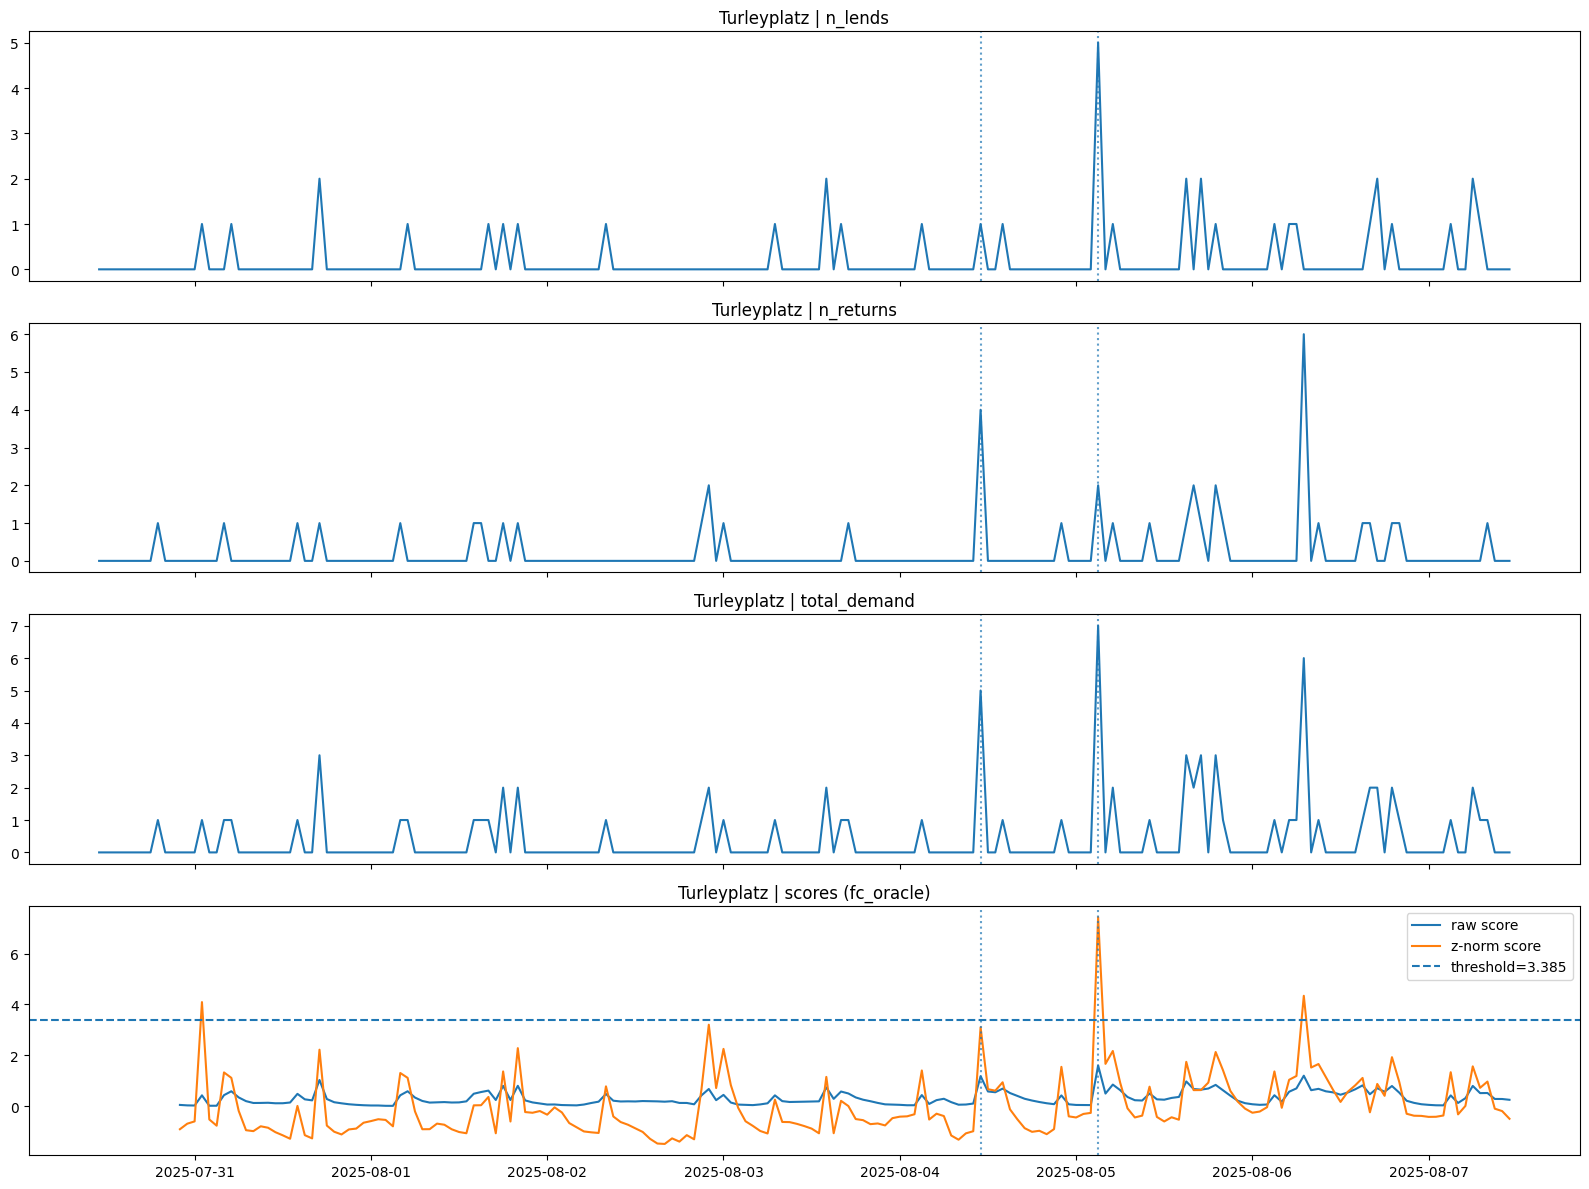

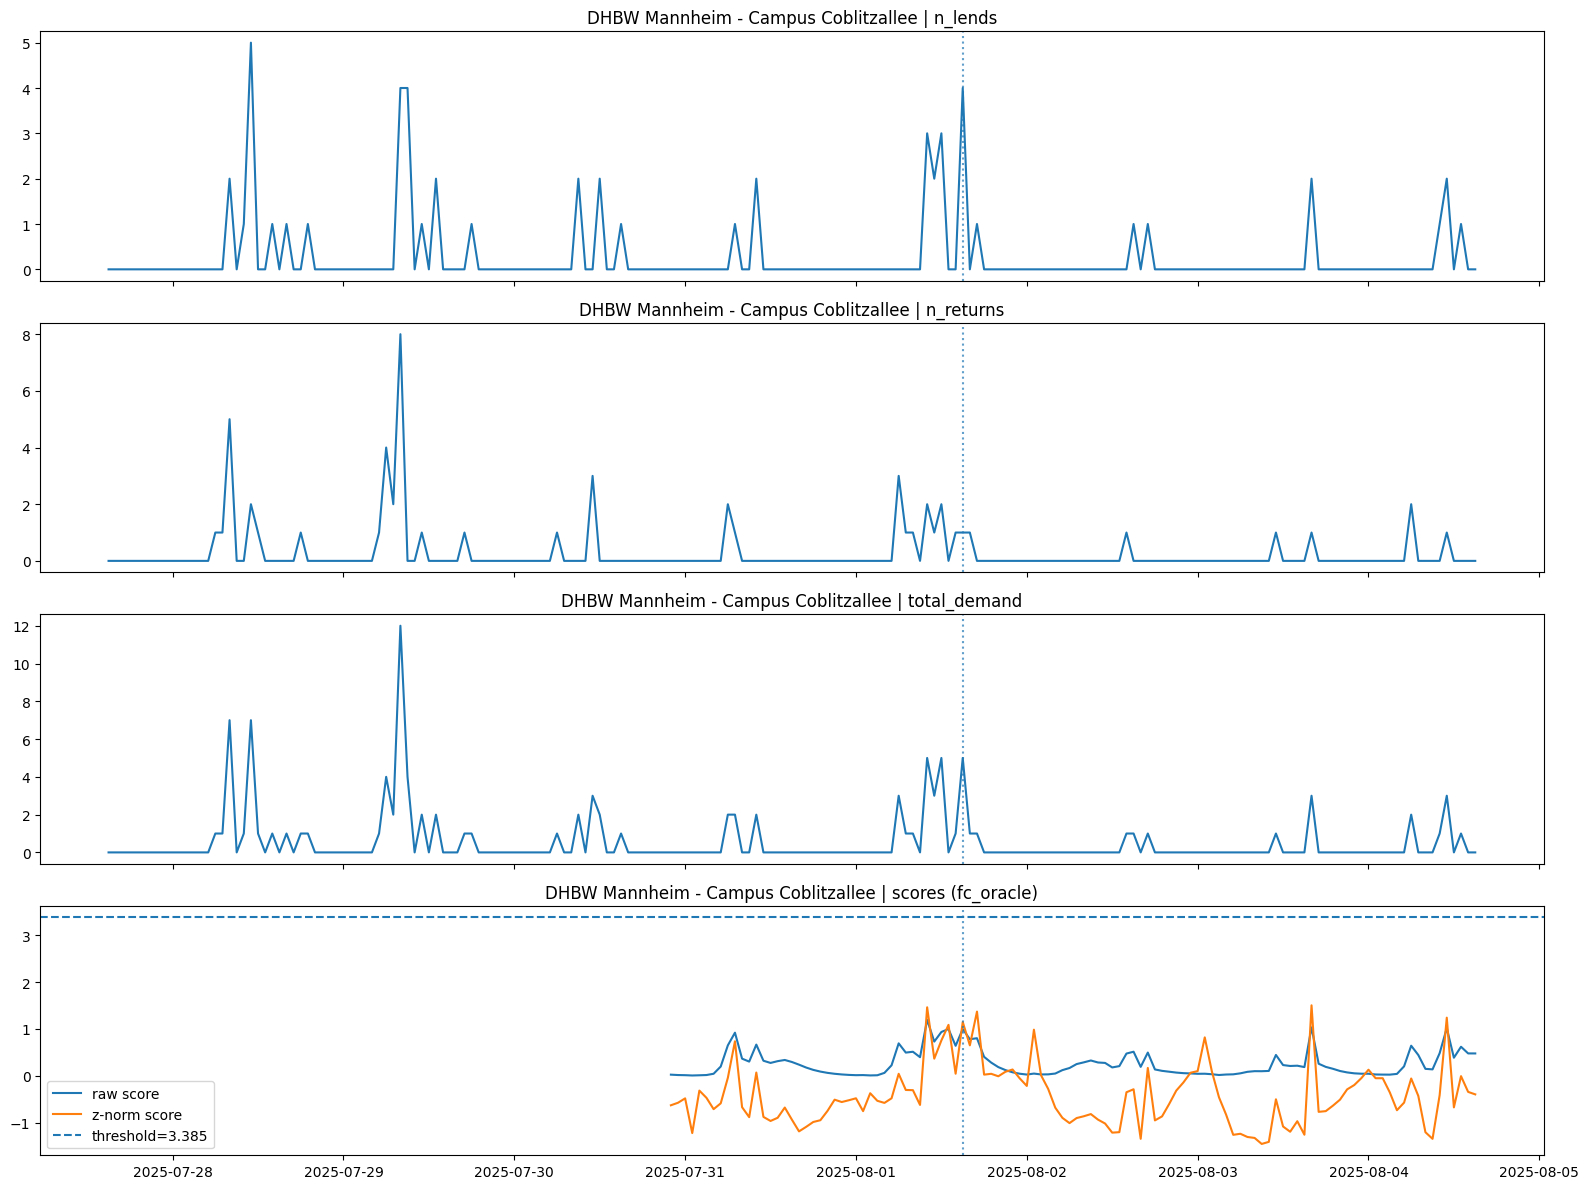

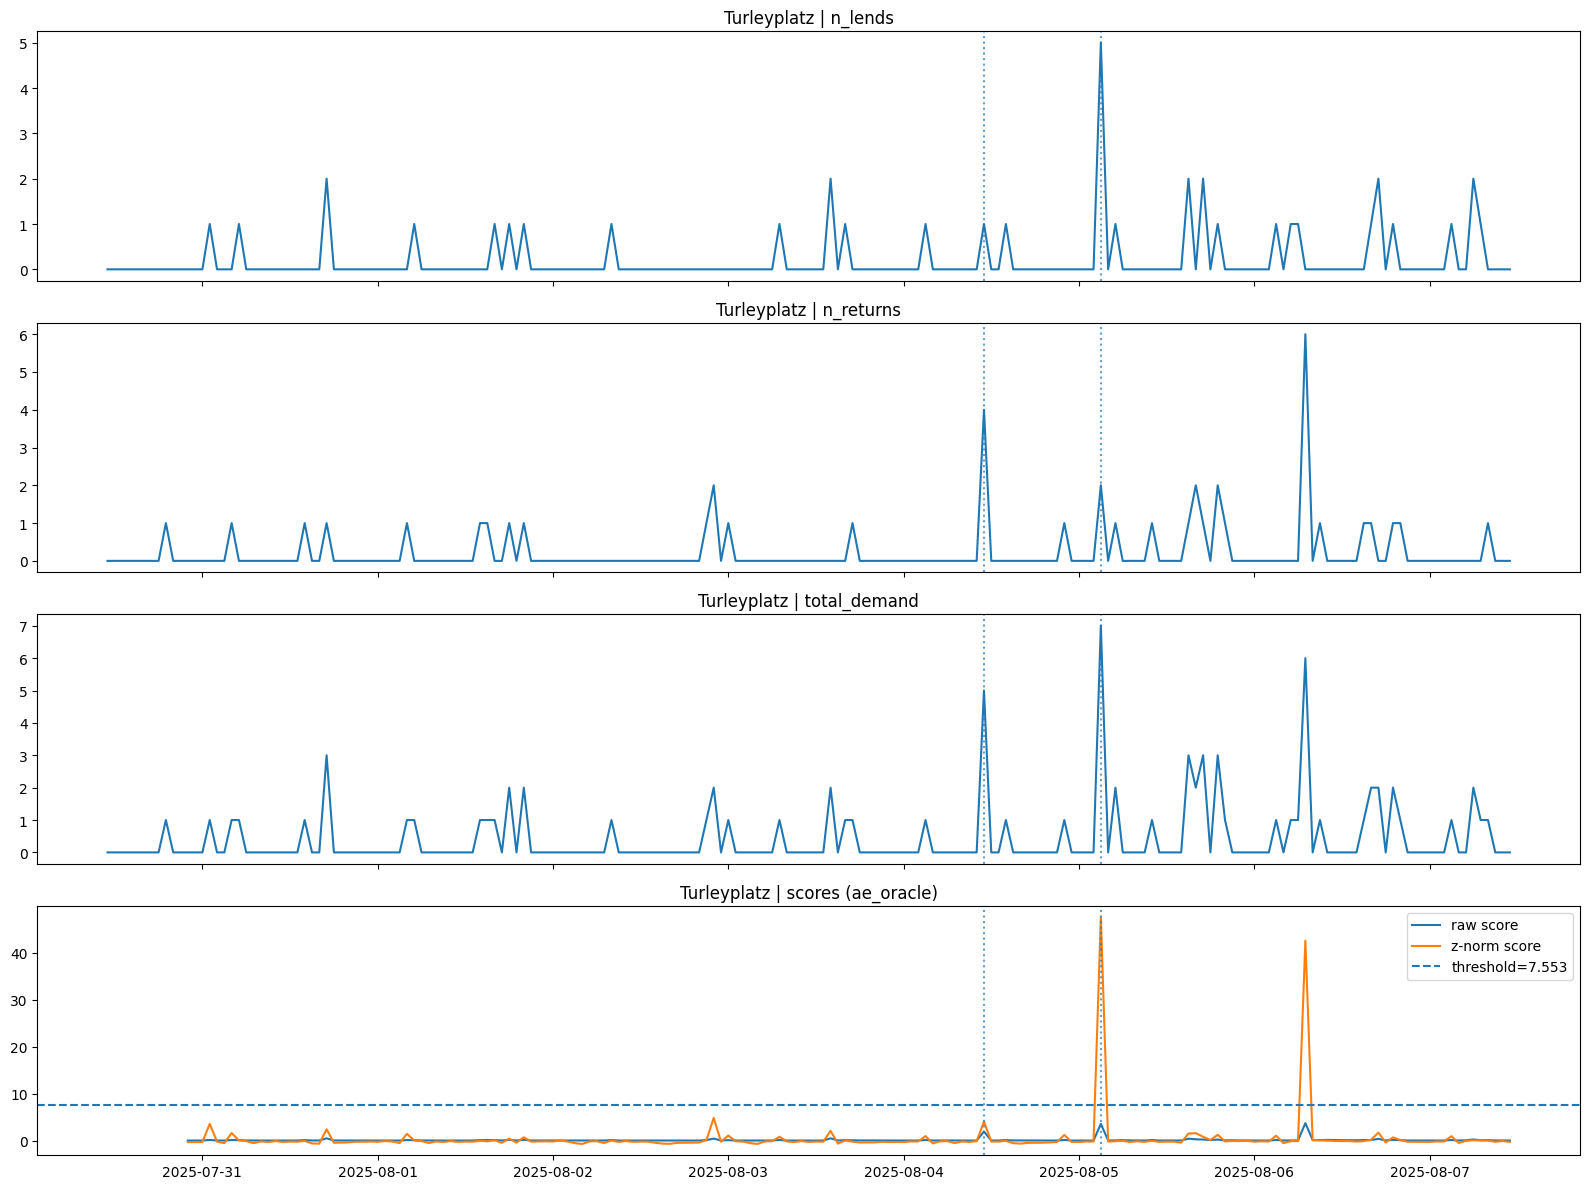

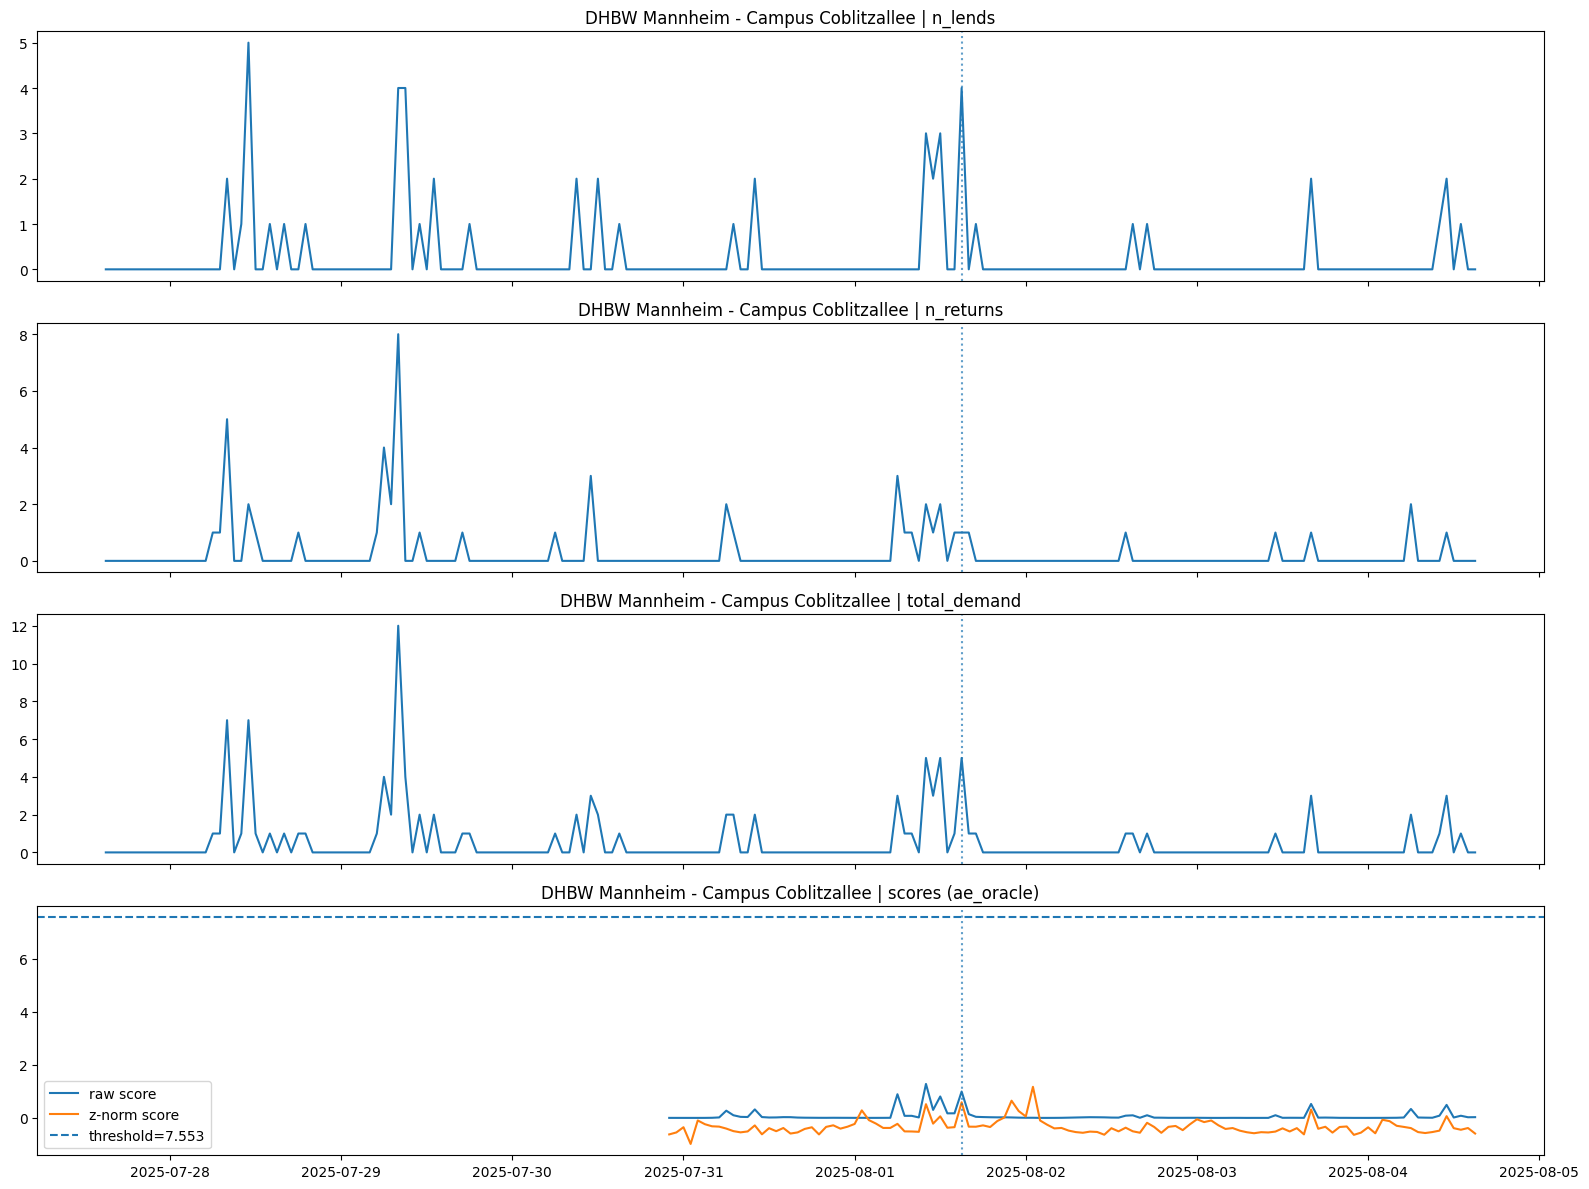

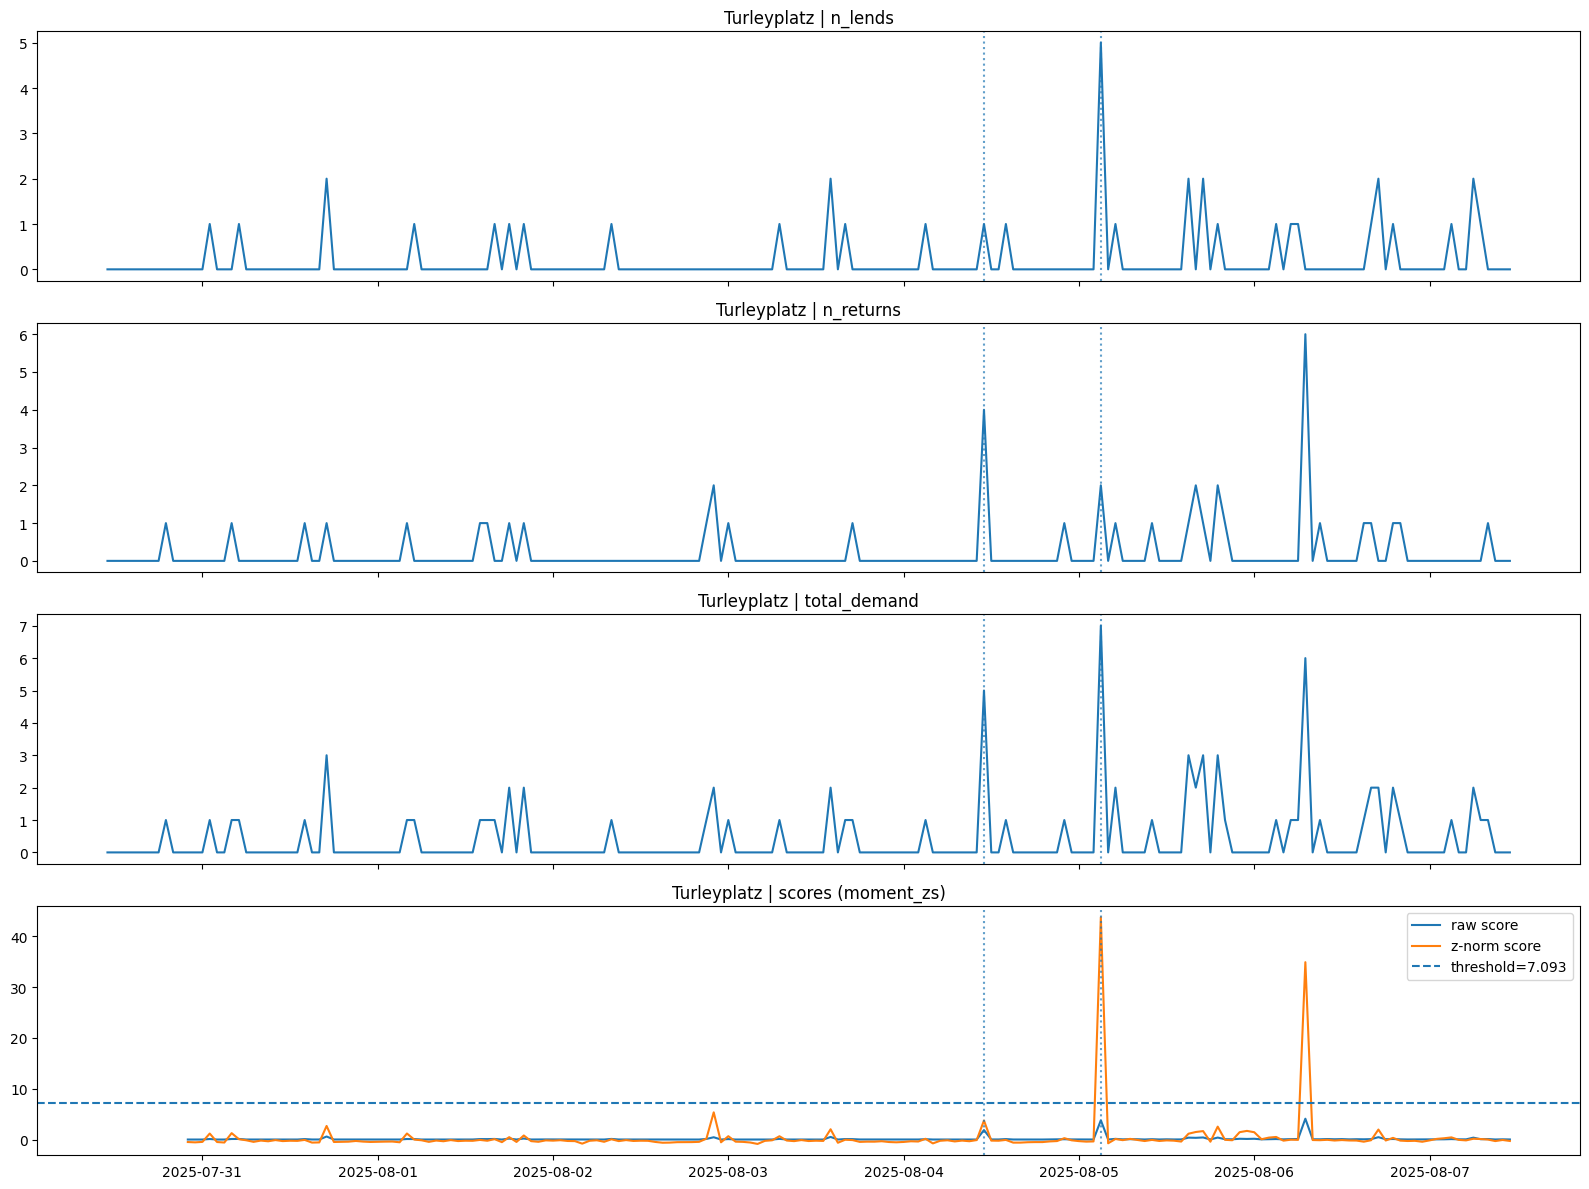

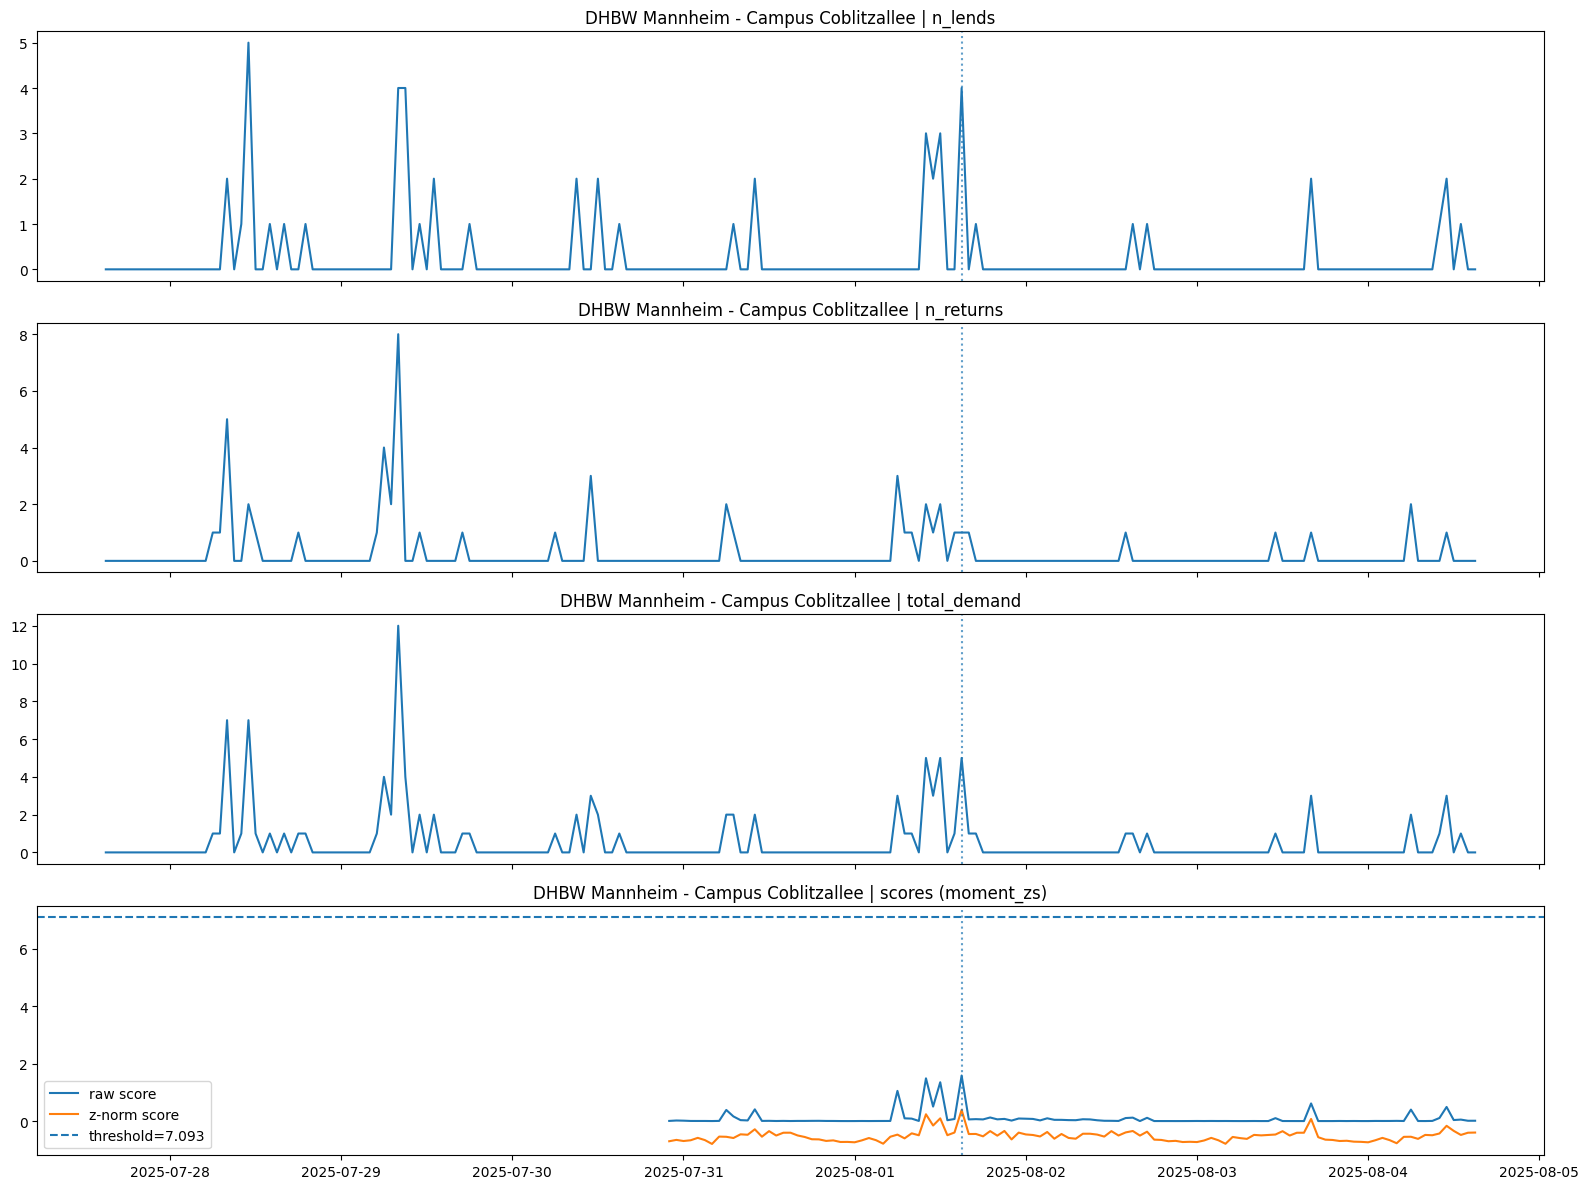

In [28]:
# Beispiel: beste / schlechteste Station aus station_fc
best_station_fc = station_fc.iloc[0]["station_id"]
worst_station_fc = station_fc.iloc[-1]["station_id"]

plot_station_diagnostics(best_station_fc, model_key="fc_oracle")
plot_station_diagnostics(worst_station_fc, model_key="fc_oracle")

plot_station_diagnostics(best_station_fc, model_key="ae_oracle")
plot_station_diagnostics(worst_station_fc, model_key="ae_oracle")

plot_station_diagnostics(best_station_fc, model_key="moment_zs")
plot_station_diagnostics(worst_station_fc, model_key="moment_zs")

In [29]:
# ══════════════════════════════════════════════════════════════
# 23 — FP/FN Analyse pro Station
# ══════════════════════════════════════════════════════════════
def build_error_table(meta, score_col, threshold, test_start):
    df = meta[meta["hour_ts"] >= test_start].copy()
    df["y_true"] = df["synth_label"].astype(int)
    df["y_pred"] = (df[score_col] >= threshold).astype(int)

    df["fp"] = ((df["y_true"] == 0) & (df["y_pred"] == 1)).astype(int)
    df["fn"] = ((df["y_true"] == 1) & (df["y_pred"] == 0)).astype(int)
    df["tp"] = ((df["y_true"] == 1) & (df["y_pred"] == 1)).astype(int)
    df["tn"] = ((df["y_true"] == 0) & (df["y_pred"] == 0)).astype(int)

    out = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              n=("y_true", "size"),
              n_anom=("y_true", "sum"),
              fp=("fp", "sum"),
              fn=("fn", "sum"),
              tp=("tp", "sum"),
              tn=("tn", "sum"),
              avg_score=(score_col, "mean"),
              avg_score_anom=(score_col, lambda s: s[df.loc[s.index, "y_true"] == 1].mean() if (df.loc[s.index, "y_true"] == 1).any() else np.nan),
              avg_score_norm=(score_col, lambda s: s[df.loc[s.index, "y_true"] == 0].mean() if (df.loc[s.index, "y_true"] == 0).any() else np.nan),
          )
    )

    out["fp_rate_on_normals"] = out["fp"] / (out["fp"] + out["tn"]).replace(0, np.nan)
    out["fn_rate_on_anoms"]   = out["fn"] / (out["fn"] + out["tp"]).replace(0, np.nan)
    out["score_gap"] = out["avg_score_anom"] - out["avg_score_norm"]

    return out.sort_values(["fn_rate_on_anoms", "fp_rate_on_normals"], ascending=False)

# Modelle
fpfn_fc = build_error_table(ma_meta, "score_fc_znorm_hs", oracle_results["FC_Oracle"]["val_threshold"], val_end_ma)
fpfn_ae = build_error_table(ma_meta, "score_ae_znorm_hs", oracle_results["AE_Oracle"]["val_threshold"], val_end_ma)
fpfn_moment = build_error_table(moment_zs_meta, "score_moment_znorm_hs", moment_zs_results["val_threshold"], val_end_ma)

print("\n=== FC: viele False Negatives ===")
print(fpfn_fc.sort_values("fn_rate_on_anoms", ascending=False).head(20).to_string(index=False))

print("\n=== FC: viele False Positives ===")
print(fpfn_fc.sort_values("fp_rate_on_normals", ascending=False).head(20).to_string(index=False))

print("\n=== AE: viele False Negatives ===")
print(fpfn_ae.sort_values("fn_rate_on_anoms", ascending=False).head(20).to_string(index=False))

print("\n=== MOMENT: viele False Negatives ===")
print(fpfn_moment.sort_values("fn_rate_on_anoms", ascending=False).head(20).to_string(index=False))


=== FC: viele False Negatives ===
station_id                         station_name    n  n_anom  fp  fn  tp   tn  avg_score  avg_score_anom  avg_score_norm  fp_rate_on_normals  fn_rate_on_anoms  score_gap
    121376           Lindenhof - Jugendherberge 4490      26  16  19   7 4448  -0.594540        3.405341       -0.617837            0.003584          0.730769   4.023178
    339352              Jungbusch - Popakademie 4489      84  18  54  30 4387  -0.261999        3.654112       -0.336676            0.004086          0.642857   3.990788
   4915747                      P7 - Fressgasse 4489      51  19  32  19 4419  -0.265087        3.348495       -0.306613            0.004281          0.627451   3.655107
  30612264                   B3 – Schillerplatz 4487      77  43  48  29 4367  -0.002112        3.227957       -0.058510            0.009751          0.623377   3.286467
   4726808  DHBW Mannheim - Campus Coblitzallee 4483      42  40  26  16 4401  -0.147024        3.514734       -0.1

In [30]:
# Beispiel: einzelne Fehlfälle inspizieren
def show_station_errors(meta, score_col, threshold, station_id, test_start, n=20):
    df = meta[(meta["station_id"] == station_id) & (meta["hour_ts"] >= test_start)].copy()
    df["y_true"] = df["synth_label"].astype(int)
    df["y_pred"] = (df[score_col] >= threshold).astype(int)

    fps = df[(df["y_true"] == 0) & (df["y_pred"] == 1)].copy()
    fns = df[(df["y_true"] == 1) & (df["y_pred"] == 0)].copy()

    print("\nFalse Positives:")
    print(fps[["hour_ts", "station_name", "synth_type", "demand_regime", score_col]].head(n).to_string(index=False))

    print("\nFalse Negatives:")
    print(fns[["hour_ts", "station_name", "synth_type", "demand_regime", score_col]].head(n).to_string(index=False))

In [31]:
# ══════════════════════════════════════════════════════════════
# 24 — Stationscharakteristika
# ══════════════════════════════════════════════════════════════
station_chars = (
    df_ma.groupby(["station_id", "station_name"], as_index=False)
         .agg(
             avg_total_demand_h=("total_demand", "mean"),
             std_total_demand_h=("total_demand", "std"),
             avg_lends_h=("n_lends", "mean"),
             avg_returns_h=("n_returns", "mean"),
             std_lends_h=("n_lends", "std"),
             std_returns_h=("n_returns", "std"),
             zero_share_total=("total_demand", lambda s: (s == 0).mean()),
             p95_total=("total_demand", lambda s: s.quantile(0.95)),
             n_hours=("hour_ts", "size"),
             latitude=("latitude", "first"),
             longitude=("longitude", "first"),
         )
)

station_chars["cv_total"] = station_chars["std_total_demand_h"] / station_chars["avg_total_demand_h"].replace(0, np.nan)
station_chars["peakiness"] = station_chars["p95_total"] / station_chars["avg_total_demand_h"].replace(0, np.nan)

# demand regime aus profile_ma oder df_ma ziehen
if "demand_regime" in df_ma.columns:
    regime_lookup = df_ma[["station_id", "demand_regime"]].drop_duplicates()
    station_chars = station_chars.merge(regime_lookup, on="station_id", how="left")

# Mit Stationsperformance mergen
station_diag_fc = station_fc.merge(station_chars, on=["station_id", "station_name"], how="left")
station_diag_ae = station_ae.merge(station_chars, on=["station_id", "station_name"], how="left")
station_diag_moment = station_moment.merge(station_chars, on=["station_id", "station_name"], how="left")

print(station_diag_fc.sort_values("pr_auc", ascending=True).head(20).to_string(index=False))

station_id                           station_name  n_test  n_anom  anomaly_rate   pr_auc  roc_auc       f1  precision   recall  mean_score_normal  mean_score_anom  score_gap  is_reliable  avg_total_demand_h  std_total_demand_h  avg_lends_h  avg_returns_h  std_lends_h  std_returns_h  zero_share_total  p95_total  n_hours  latitude  longitude  cv_total  peakiness demand_regime
   4726808    DHBW Mannheim - Campus Coblitzallee    4483      42      0.009369 0.221225 0.962326 0.326531   0.285714 0.380952          -0.181654         3.514734   3.696388         True            1.100465            2.444065     0.551035       0.549430     1.596375       1.753772          0.687650        6.0    24924    49.473      8.534  2.220938   5.452239           mid
  33282236                               Eastsite    4486      34      0.007579 0.233824 0.987540 0.365079   0.250000 0.676471           0.025085         4.942177   4.917092         True            0.365405            0.848041     0.183485       

In [32]:
num_cols = [
    "avg_total_demand_h", "std_total_demand_h", "zero_share_total",
    "cv_total", "peakiness", "n_hours", "pr_auc", "f1", "score_gap"
]

print("\n=== FC Korrelationen ===")
print(station_diag_fc[num_cols].corr(numeric_only=True)["pr_auc"].sort_values(ascending=False))

print("\n=== AE Korrelationen ===")
print(station_diag_ae[num_cols].corr(numeric_only=True)["pr_auc"].sort_values(ascending=False))

print("\n=== MOMENT Korrelationen ===")
print(station_diag_moment[num_cols].corr(numeric_only=True)["pr_auc"].sort_values(ascending=False))


=== FC Korrelationen ===
pr_auc                1.000000
f1                    0.739663
n_hours               0.086804
avg_total_demand_h    0.070979
std_total_demand_h   -0.048932
score_gap            -0.150460
zero_share_total     -0.341606
cv_total             -0.438910
peakiness            -0.447335
Name: pr_auc, dtype: float64

=== AE Korrelationen ===
pr_auc                1.000000
f1                    0.829003
zero_share_total      0.008295
score_gap            -0.016493
n_hours              -0.058722
peakiness            -0.164541
cv_total             -0.220285
avg_total_demand_h   -0.241619
std_total_demand_h   -0.324740
Name: pr_auc, dtype: float64

=== MOMENT Korrelationen ===
pr_auc                1.000000
f1                    0.840049
score_gap             0.235328
zero_share_total      0.129370
peakiness            -0.082186
n_hours              -0.092222
cv_total             -0.139011
avg_total_demand_h   -0.391067
std_total_demand_h   -0.465443
Name: pr_auc, dtype: fl